# **Section 1 — Data Preprocessing & Feature Extraction**

*   Setting up libraries, global constants, and sensor grid configuration (34×16 circular mask)
*   Defining the three-stage signal preprocessing pipeline: Energy Normalization → Whitening Transform → Z-Score Normalization
*   Helper utilities for parsing condition labels (Normal / Low Iron) from file names and computing energy concentration metrics
*   Parallel feature extraction from raw CSV files, producing a feature matrix with 35+ features per frame covering signal statistics, spatial entropy, radial ring energies, zone energies, radial decay, and concentration ratios

*   Verifying participant count and detecting duplicate subject identifiers
Visualizing the full preprocessing pipeline across 6 stages for a selected sample frame


In [ ]:
# ============================================================
# الخلية 1: المكتبات والإعدادات (نسخة Jupyter المحلية)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os, re, time, math, warnings
from scipy.linalg import sqrtm, inv
from scipy.stats import kurtosis, skew, entropy, ttest_ind
from scipy.interpolate import griddata
from IPython.display import display

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (16, 6)
sns.set_style('whitegrid')

# ── إعدادات الشبكة ───────────────────────────────────────────
ROWS, COLS         = 34, 16
CENTER_ROW         = 16.5
CENTER_COL         = 7.5
RADIUS             = 6.0
EPS                = 1e-10
WEIGHT_THRESHOLD   = 0.01
STABLE_WINDOW_TRIM = 0.20

# ── القناع الدائري ────────────────────────────────────────────
_ri, _ci = np.indices((ROWS, COLS))
MASK_2D  = np.sqrt((_ri - CENTER_ROW)**2 + (_ci - CENTER_COL)**2) <= RADIUS
N_ACTIVE_PIXELS = int(MASK_2D.sum())

# ── إحداثيات ثابتة (تُحسب مرة واحدة) ────────────────────────
_y_idx, _x_idx = np.indices((ROWS, COLS))
COORDS_FLAT     = np.stack([_x_idx.ravel(), _y_idx.ravel()], axis=0).astype(float)

print(f"✅ الإعدادات جاهزة — عدد البكسلات النشطة في الحساس: {N_ACTIVE_PIXELS}")

✅ الإعدادات جاهزة — عدد البكسلات النشطة في الحساس: 112


In [ ]:
# ============================================================
# الخلية 2: دوال معالجة وتنظيف الإشارات
# ============================================================
def apply_energy_normalization(frame_2d):
    e = np.clip(frame_2d, 0, None)
    s = np.sum(e)
    return e / s if s > 0 else e

def apply_whitening_transform(energy_map):
    rows, cols   = energy_map.shape
    coords       = np.stack([np.arange(cols * rows) % cols,
                              np.arange(cols * rows) // cols], axis=0).astype(float)
    weights      = energy_map.ravel()
    total_weight = np.sum(weights)

    if total_weight <= 0:
        return energy_map

    mean_pos = np.sum(coords * weights, axis=1, keepdims=True) / total_weight
    centered = coords - mean_pos
    cov      = (centered * weights) @ centered.T / total_weight
    cov      = (cov + cov.T) / 2

    try:
        W       = inv(sqrtm(cov + np.eye(2) * 1e-6))
        wc      = W @ centered
        wx, wy  = wc[0], wc[1]

        def rescale(arr, lo, hi):
            a, b = arr.min(), arr.max()
            if a == b: return np.full_like(arr, (lo + hi) / 2)
            return (arr - a) / (b - a) * (hi - lo) + lo

        wx_s   = rescale(wx, 0, cols - 1)
        wy_s   = rescale(wy, 0, rows - 1)
        gy, gx = np.mgrid[0:rows, 0:cols]
        w_map  = griddata(np.stack([wx_s, wy_s], axis=1),
                          weights, (gx, gy),
                          method='linear', fill_value=0.0)
        return np.clip(w_map, 0, None)

    except Exception as e:
        warnings.warn(f"Whitening failed: {e}")
        return energy_map

def apply_zscore_normalization(energy_map):
    mean_v = np.mean(energy_map)
    std_v  = np.std(energy_map)
    z      = (energy_map - mean_v) / (std_v if std_v > 0 else 1.0)
    z      = z - np.min(z)
    s      = np.sum(z)
    return z / s if s > 0 else z

print("✅ دوال التنظيف (Pipeline) جاهزة")

✅ دوال التنظيف (Pipeline) جاهزة


In [ ]:
# ============================================================
# الخلية 3: دوال المساعدة
# ============================================================
_COND_PATTERN = re.compile(r'[-_]?[FMfm][-_]?([LN])\d*$|[-_]([LN])\d*$')

def parse_condition(filepath):
    name  = os.path.basename(filepath).upper().replace('.CSV', '')
    match = _COND_PATTERN.search(name)
    if not match: return None
    letter = match.group(1) or match.group(2)
    return 'Normal' if letter == 'N' else 'Low Iron'

def top_n_energy(sorted_desc, total, pct):
    k = max(1, int(np.ceil(len(sorted_desc) * pct)))
    return np.sum(sorted_desc[:k]) / (total + EPS)

print("✅ دوال المساعدة جاهزة")

✅ دوال المساعدة جاهزة


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# الخلية 4: استخراج الميزات بسرعة خارقة مع طباعة الملفات (نسخة Threading)
# ============================================================
from joblib import Parallel, delayed
import time
import datetime
import glob, os
import pandas as pd
import numpy as np
from scipy.stats import kurtosis, skew, entropy

folder_path = '/content/drive/MyDrive/rawData'
csv_files   = glob.glob(os.path.join(folder_path, "*.csv"))

if len(csv_files) == 0:
    print("❌ لم يتم العثور على أي ملفات! تأكدي من المسار.")
else:
    print(f"🚀 ممتاز! تم العثور على {len(csv_files)} ملف.")
    print("⚡ بدء تشغيل المعالجات المتوازية (ستظهر الملفات هنا مباشرة)...\n")
    start_time = time.time()

    def process_single_file(file):
        # طباعة اسم الملف فور بدء معالجته (الآن ستظهر في جوبيتر فوراً)
        print(f"🔄 جاري معالجة: {os.path.basename(file)} ...")

        file_dataset = []
        condition = parse_condition(file)
        if condition is None: return file_dataset

        try:
            df = pd.read_csv(file, on_bad_lines='skip')
            for idx in range(len(df)):
                delta_str = (str(df['delta_values'].iloc[idx]).replace('OK 34 16', '').replace('\n', ''))
                try: delta_raw = np.array([float(x.strip()) for x in delta_str.split(',') if x.strip()])
                except: continue

                if len(delta_raw) != 544: continue

                raw_2d           = delta_raw.reshape(ROWS, COLS).copy()
                raw_2d[~MASK_2D] = 0
                energy_map       = apply_energy_normalization(raw_2d)
                whitened_map     = apply_whitening_transform(energy_map)
                final_map        = apply_zscore_normalization(whitened_map)

                flat   = final_map.flatten()
                active = flat[flat > 0]
                if len(active) < 5: continue

                ff = {'source_file': file, 'Condition': condition, 'frame_index': idx}

                p_norm       = active / (np.sum(active) + EPS)
                sorted_desc  = np.sort(active)[::-1]
                sorted_asc   = sorted_desc[::-1]
                total_energy = np.sum(active)
                n_px         = len(active)

                ff['signal_mean']              = np.mean(active)
                ff['signal_std']               = np.std(active)
                ff['signal_variance']          = np.var(active)
                ff['active_area']              = n_px
                ff['peak_amplitude']           = sorted_desc[0]
                ff['signal_power']             = np.mean(active ** 2)
                ff['rms_amplitude']            = np.sqrt(ff['signal_power'])
                ff['crest_factor']             = ff['peak_amplitude'] / (ff['rms_amplitude'] + EPS)
                ff['kurtosis']                 = kurtosis(active, fisher=True)
                ff['skewness']                 = skew(active)
                ff['coefficient_of_variation'] = ff['signal_std'] / (ff['signal_mean'] + EPS)

                raw_ent               = entropy(p_norm)
                ff['spatial_entropy'] = raw_ent
                max_ent               = np.log(n_px) if n_px > 1 else 1.0
                ff['entropy_norm']    = raw_ent / (max_ent + EPS)

                ff['top_50_energy'] = top_n_energy(sorted_desc, total_energy, 0.50)
                ff['top_25_energy'] = top_n_energy(sorted_desc, total_energy, 0.25)
                ff['top_10_energy'] = top_n_energy(sorted_desc, total_energy, 0.10)

                cumsum = np.cumsum(sorted_asc)
                if cumsum[-1] > 0:
                    gini_raw = (2 * np.sum(np.arange(1, n_px + 1) * sorted_asc) / (n_px * cumsum[-1]) - (n_px + 1) / n_px)
                    ff['gini_coefficient'] = float(np.clip(gini_raw, 0.0, 1.0))
                else: ff['gini_coefficient'] = 0.0

                p_sq_sum                   = np.sum(p_norm ** 2)
                ff['effective_area_ratio'] = (1.0 / (p_sq_sum + EPS)) / (N_ACTIVE_PIXELS + EPS)
                ff['contact_compactness']  = n_px / (N_ACTIVE_PIXELS + EPS)

                weights, t_w = flat, np.sum(flat)
                r_features   = {f'ring{k}_energy': 0.0 for k in range(1, 6)}
                z_features   = {'core_energy': 0.0, 'mid_energy': 0.0, 'boundary_energy': 0.0, 'center_dominance': 0.0}
                decay_features = {'radial_slope': 0.0, 'radial_curvature': 0.0, 'radial_spread': 0.0, 'radial_variance': 0.0, 'radial_std': 0.0, 'radial_kurtosis': 0.0}

                if t_w > 0:
                    mean_pos    = np.sum(COORDS_FLAT * weights, axis=1, keepdims=True) / t_w
                    centered    = COORDS_FLAT - mean_pos
                    radial_dist = np.sqrt(centered[0] ** 2 + centered[1] ** 2)
                    active_mask = weights > (weights.max() * WEIGHT_THRESHOLD)

                    if active_mask.sum() >= 5:
                        active_dists, active_weights, t_w_active = radial_dist[active_mask], weights[active_mask], np.sum(weights[active_mask])

                        bounds_r = ([0] + np.percentile(active_dists, [20, 40, 60, 80]).tolist() + [np.inf])
                        for k in range(5):
                            mask_k = ((radial_dist >= bounds_r[k]) & (radial_dist <  bounds_r[k + 1]))
                            r_features[f'ring{k+1}_energy'] = (np.sum(weights[mask_k]) / (t_w_active + EPS))

                        p33, p66 = np.percentile(active_dists, [33, 66])
                        c_e = np.sum(weights[radial_dist < p33]) / (t_w_active + EPS)
                        m_e = np.sum(weights[(radial_dist >= p33) & (radial_dist < p66)]) / (t_w_active + EPS)
                        b_e = np.sum(weights[radial_dist >= p66]) / (t_w_active + EPS)
                        z_features = {'core_energy': c_e, 'mid_energy': m_e, 'boundary_energy': b_e, 'center_dominance': c_e - b_e}

                        norm_dist    = active_dists / (active_dists.max() + EPS)
                        norm_weights = active_weights / (active_weights.sum() + EPS)

                        decay_features['radial_slope']     = np.polyfit(norm_dist, active_weights, 1, w=norm_weights)[0]
                        decay_features['radial_curvature'] = np.polyfit(norm_dist, active_weights, 2, w=norm_weights)[0]
                        r_spread = np.sum(norm_dist * norm_weights)
                        r_var    = np.sum(norm_weights * (norm_dist - r_spread) ** 2)
                        decay_features['radial_spread']    = r_spread
                        decay_features['radial_variance']  = r_var
                        decay_features['radial_std']       = np.sqrt(r_var)

                        if r_var > EPS:
                            decay_features['radial_kurtosis'] = np.sum(norm_weights * (norm_dist - r_spread) ** 4) / (r_var ** 2 + EPS)

                ff.update(r_features)
                ff.update(z_features)
                ff.update(decay_features)

                ff['ring_decay_ratio']    = r_features['ring1_energy'] / (r_features['ring5_energy'] + EPS)
                ff['inner_outer_ratio']   = ((r_features['ring1_energy'] + r_features['ring2_energy']) / (r_features['ring4_energy'] + r_features['ring5_energy'] + EPS))
                ff['core_mid_ratio']      = z_features['core_energy'] / (z_features['mid_energy'] + EPS)
                ff['core_boundary_ratio'] = z_features['core_energy'] / (z_features['boundary_energy'] + EPS)
                ff['mid_boundary_ratio']  = z_features['mid_energy']  / (z_features['boundary_energy'] + EPS)

                file_dataset.append(ff)
        except Exception as e: pass
        return file_dataset

    # التغيير السحري هنا: استخدام backend='threading' لكي يطبع مباشرة في جوبيتر
    parallel_results = Parallel(n_jobs=-1, backend='loky')(delayed(process_single_file)(f) for f in csv_files)

    # تجميع النتائج
    ml_dataset = [item for sublist in parallel_results for item in sublist]
    ml_df  = pd.DataFrame(ml_dataset)
    n_feat = len([c for c in ml_df.columns if c not in ['source_file', 'Condition', 'frame_index']])

    print("\n" + "="*60)
    print(f"✅ اكتملت المهمة! الوقت المستغرق: {str(datetime.timedelta(seconds=int(time.time() - start_time)))}")
    print(f"📊 إجمالي البيانات: {len(ml_df):,} إطار × {n_feat} ميزة")
    print("="*60)

🚀 ممتاز! تم العثور على 70 ملف.
⚡ بدء تشغيل المعالجات المتوازية (ستظهر الملفات هنا مباشرة)...


✅ اكتملت المهمة! الوقت المستغرق: 0:03:17
📊 إجمالي البيانات: 19,175 إطار × 39 ميزة


In [ ]:
# ============================================================
# خلية فحص أسماء المشاركين (لاكتشاف الملفات الزائدة)
# ============================================================
import re
import os

def get_subject_id(filename):
    name = os.path.basename(filename).upper()
    match = re.search(r'(?:R\d+[-_])([A-Z]+)', name)
    return match.group(1) if match else name

unique_names = ml_df['source_file'].apply(get_subject_id).unique()

print(f"🕵️‍♀️ عدد المشاركين الذين وجدهم الكود: {len(unique_names)}")
print("الأسماء هي:")
print("-" * 30)
for name in unique_names:
    print(f"🔹 {name}")
print("-" * 30)

🕵️‍♀️ عدد المشاركين الذين وجدهم الكود: 18
الأسماء هي:
------------------------------
🔹 AMAL
🔹 ASAL
🔹 BUSHRA
🔹 LAMYA
🔹 MALAK
🔹 MNAR
🔹 RETAJ
🔹 REYOUF
🔹 SOHAILA
🔹 SUMAYAH
🔹 HAMMED
🔹 MAHA
🔹 RAGHAD
🔹 REFAL
🔹 ALSHAYMAA
🔹 FANAR
🔹 KHALAF
🔹 MUNIRA
------------------------------


Selected:  R1-MNAR3-F-L.csv  |  Frame 55  |  Low Iron


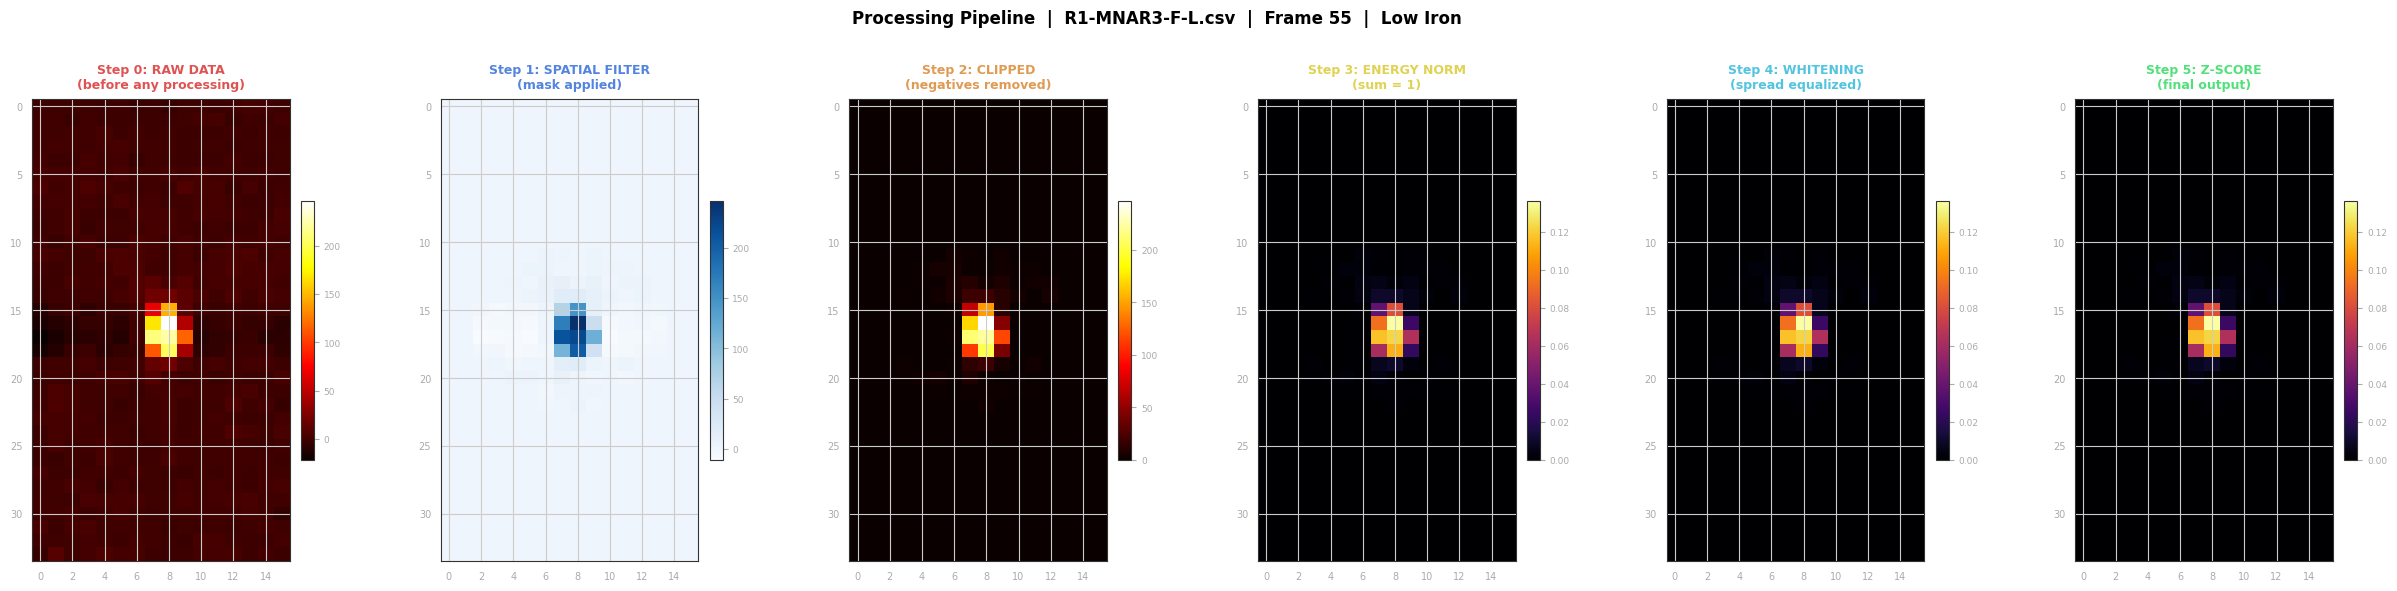

Saved: pipeline_visualization.png


In [ ]:
# ============================================================
# Cell 5: Pipeline Visualization — Pick your own sample
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# ── ضمان وجود دالات المعالجة وتوافقها مع البيئة الحالية ───────
if 'apply_energy_normalization' not in locals():
    def apply_energy_normalization(frame_2d):
        e = np.clip(frame_2d, 0, None)
        s = np.sum(e)
        return e / s if s > 0 else e

if 'apply_whitening_transform' not in locals():
    def apply_whitening_transform(energy_map):
        rows, cols   = energy_map.shape
        coords       = np.stack([np.arange(cols * rows) % cols,
                                  np.arange(cols * rows) // cols], axis=0).astype(float)
        weights      = energy_map.ravel()
        total_weight = np.sum(weights)
        if total_weight <= 0: return energy_map
        mean_pos = np.sum(coords * weights, axis=1, keepdims=True) / total_weight
        centered = coords - mean_pos
        cov      = (centered * weights) @ centered.T / total_weight
        cov      = (cov + cov.T) / 2
        try:
            from scipy.linalg import sqrtm, inv
            from scipy.interpolate import griddata
            W       = inv(sqrtm(cov + np.eye(2) * 1e-6))
            wc      = W @ centered
            wx, wy  = wc[0], wc[1]
            def rescale(arr, lo, hi):
                a, b = arr.min(), arr.max()
                if a == b: return np.full_like(arr, (lo + hi) / 2)
                return (arr - a) / (b - a) * (hi - lo) + lo
            wx_s   = rescale(wx, 0, cols - 1)
            wy_s   = rescale(wy, 0, rows - 1)
            gy, gx = np.mgrid[0:rows, 0:cols]
            w_map  = griddata(np.stack([wx_s, wy_s], axis=1),
                              weights, (gx, gy),
                              method='linear', fill_value=0.0)
            return np.clip(w_map, 0, None)
        except:
            return energy_map

if 'apply_zscore_normalization' not in locals():
    def apply_zscore_normalization(energy_map):
        mean_v = np.mean(energy_map)
        std_v  = np.std(energy_map)
        z      = (energy_map - mean_v) / (std_v if std_v > 0 else 1.0)
        z      = z - np.min(z)
        s      = np.sum(z)
        return z / s if s > 0 else z

# ── Choose your sample ───────────────────────────────────────
ROW_INDEX        = 55
FILTER_CONDITION = 'Low Iron'    # 'Normal'  or  'Low Iron'  or  None
FILTER_FILE      = 'R1-MNAR3-F-L.csv'  # partial file name  or  None

# ── Apply filters (تم تعديل الاسم هنا ليطابق ملفك ml_df) ──────
subset = ml_df.copy()
if FILTER_CONDITION:
    subset = subset[subset['Condition'] == FILTER_CONDITION]
if FILTER_FILE:
    subset = subset[subset['source_file'].str.contains(FILTER_FILE, case=False)]
if subset.empty:
    raise ValueError("No rows match your filters.")

sample_row   = subset.iloc[ROW_INDEX]
SAMPLE_FILE  = sample_row['source_file']
SAMPLE_FRAME = sample_row['frame_index']
cond_label   = sample_row['Condition']

print(f"Selected:  {os.path.basename(SAMPLE_FILE)}  |  Frame {SAMPLE_FRAME}  |  {cond_label}")

# ── Re-read raw frame ────────────────────────────────────────
df_raw    = pd.read_csv(SAMPLE_FILE, on_bad_lines='skip')
row       = df_raw.iloc[SAMPLE_FRAME]
delta_str = str(row['delta_values']).replace('OK 34 16', '').replace('\n', '')
delta_raw = np.array([float(x.strip()) for x in delta_str.split(',') if x.strip()])
raw_2d    = delta_raw.reshape(ROWS, COLS).copy()

# ── Pipeline stages ──────────────────────────────────────────
stage0_raw     = raw_2d.copy()
stage1_masked  = raw_2d.copy();  stage1_masked[~MASK_2D] = 0
stage2_cleaned = np.clip(stage1_masked, 0, None)
stage3_energy  = apply_energy_normalization(stage2_cleaned)
stage4_white   = apply_whitening_transform(stage3_energy)
stage5_zscore  = apply_zscore_normalization(stage4_white)

stages = [
    (stage0_raw,     'Step 0: RAW DATA\n(before any processing)', 'hot',     '#E05252'),
    (stage1_masked,  'Step 1: SPATIAL FILTER\n(mask applied)',    'Blues',   '#5284E0'),
    (stage2_cleaned, 'Step 2: CLIPPED\n(negatives removed)',      'hot',     '#E09A52'),
    (stage3_energy,  'Step 3: ENERGY NORM\n(sum = 1)',            'inferno', '#E0D252'),
    (stage4_white,   'Step 4: WHITENING\n(spread equalized)',     'inferno', '#52C4E0'),
    (stage5_zscore,  'Step 5: Z-SCORE\n(final output)',           'inferno', '#52E07A'),
]

# ── Plot ─────────────────────────────────────────────────────
BG_COLOR = '#FFFFFF'
fname    = os.path.basename(SAMPLE_FILE)

fig, axes = plt.subplots(
    nrows=1, ncols=len(stages),
    figsize=(len(stages) * 5, 6),   # wider per plot so nothing is cramped
    facecolor=BG_COLOR
)
fig.subplots_adjust(wspace=0.45)    # ← spacing between plots

fig.suptitle(
    f'Processing Pipeline  |  {fname}  |  Frame {SAMPLE_FRAME}  |  {cond_label}',
    fontsize=12, color='black', y=1.03, fontweight='bold'
)

for ax, (data, title, cmap, title_color) in zip(axes, stages):
    im = ax.imshow(data, cmap=cmap, aspect='auto', interpolation='nearest')
    ax.set_title(title, fontsize=9, color=title_color, fontweight='bold', pad=8)
    ax.tick_params(colors='#AAAAAA', labelsize=7)
    ax.set_facecolor(BG_COLOR)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.tick_params(labelsize=6.5, colors='#AAAAAA')
    cb.outline.set_edgecolor('#333333')

plt.savefig('pipeline_visualization.png', dpi=150,
            bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print("Saved: pipeline_visualization.png")

# ****

# **Section 2 — Exploratory Data Analysis & Feature Evaluation**



*   Visualizing the distribution of all extracted features using boxplots and grouped bar charts, comparing Normal vs. Low Iron conditions across all frames
*   Statistically evaluating each feature using Welch t-test and Cohen's d effect size, ranking features by discriminative power and labeling them as Excellent / Good / Weak / Non-significant



# ****

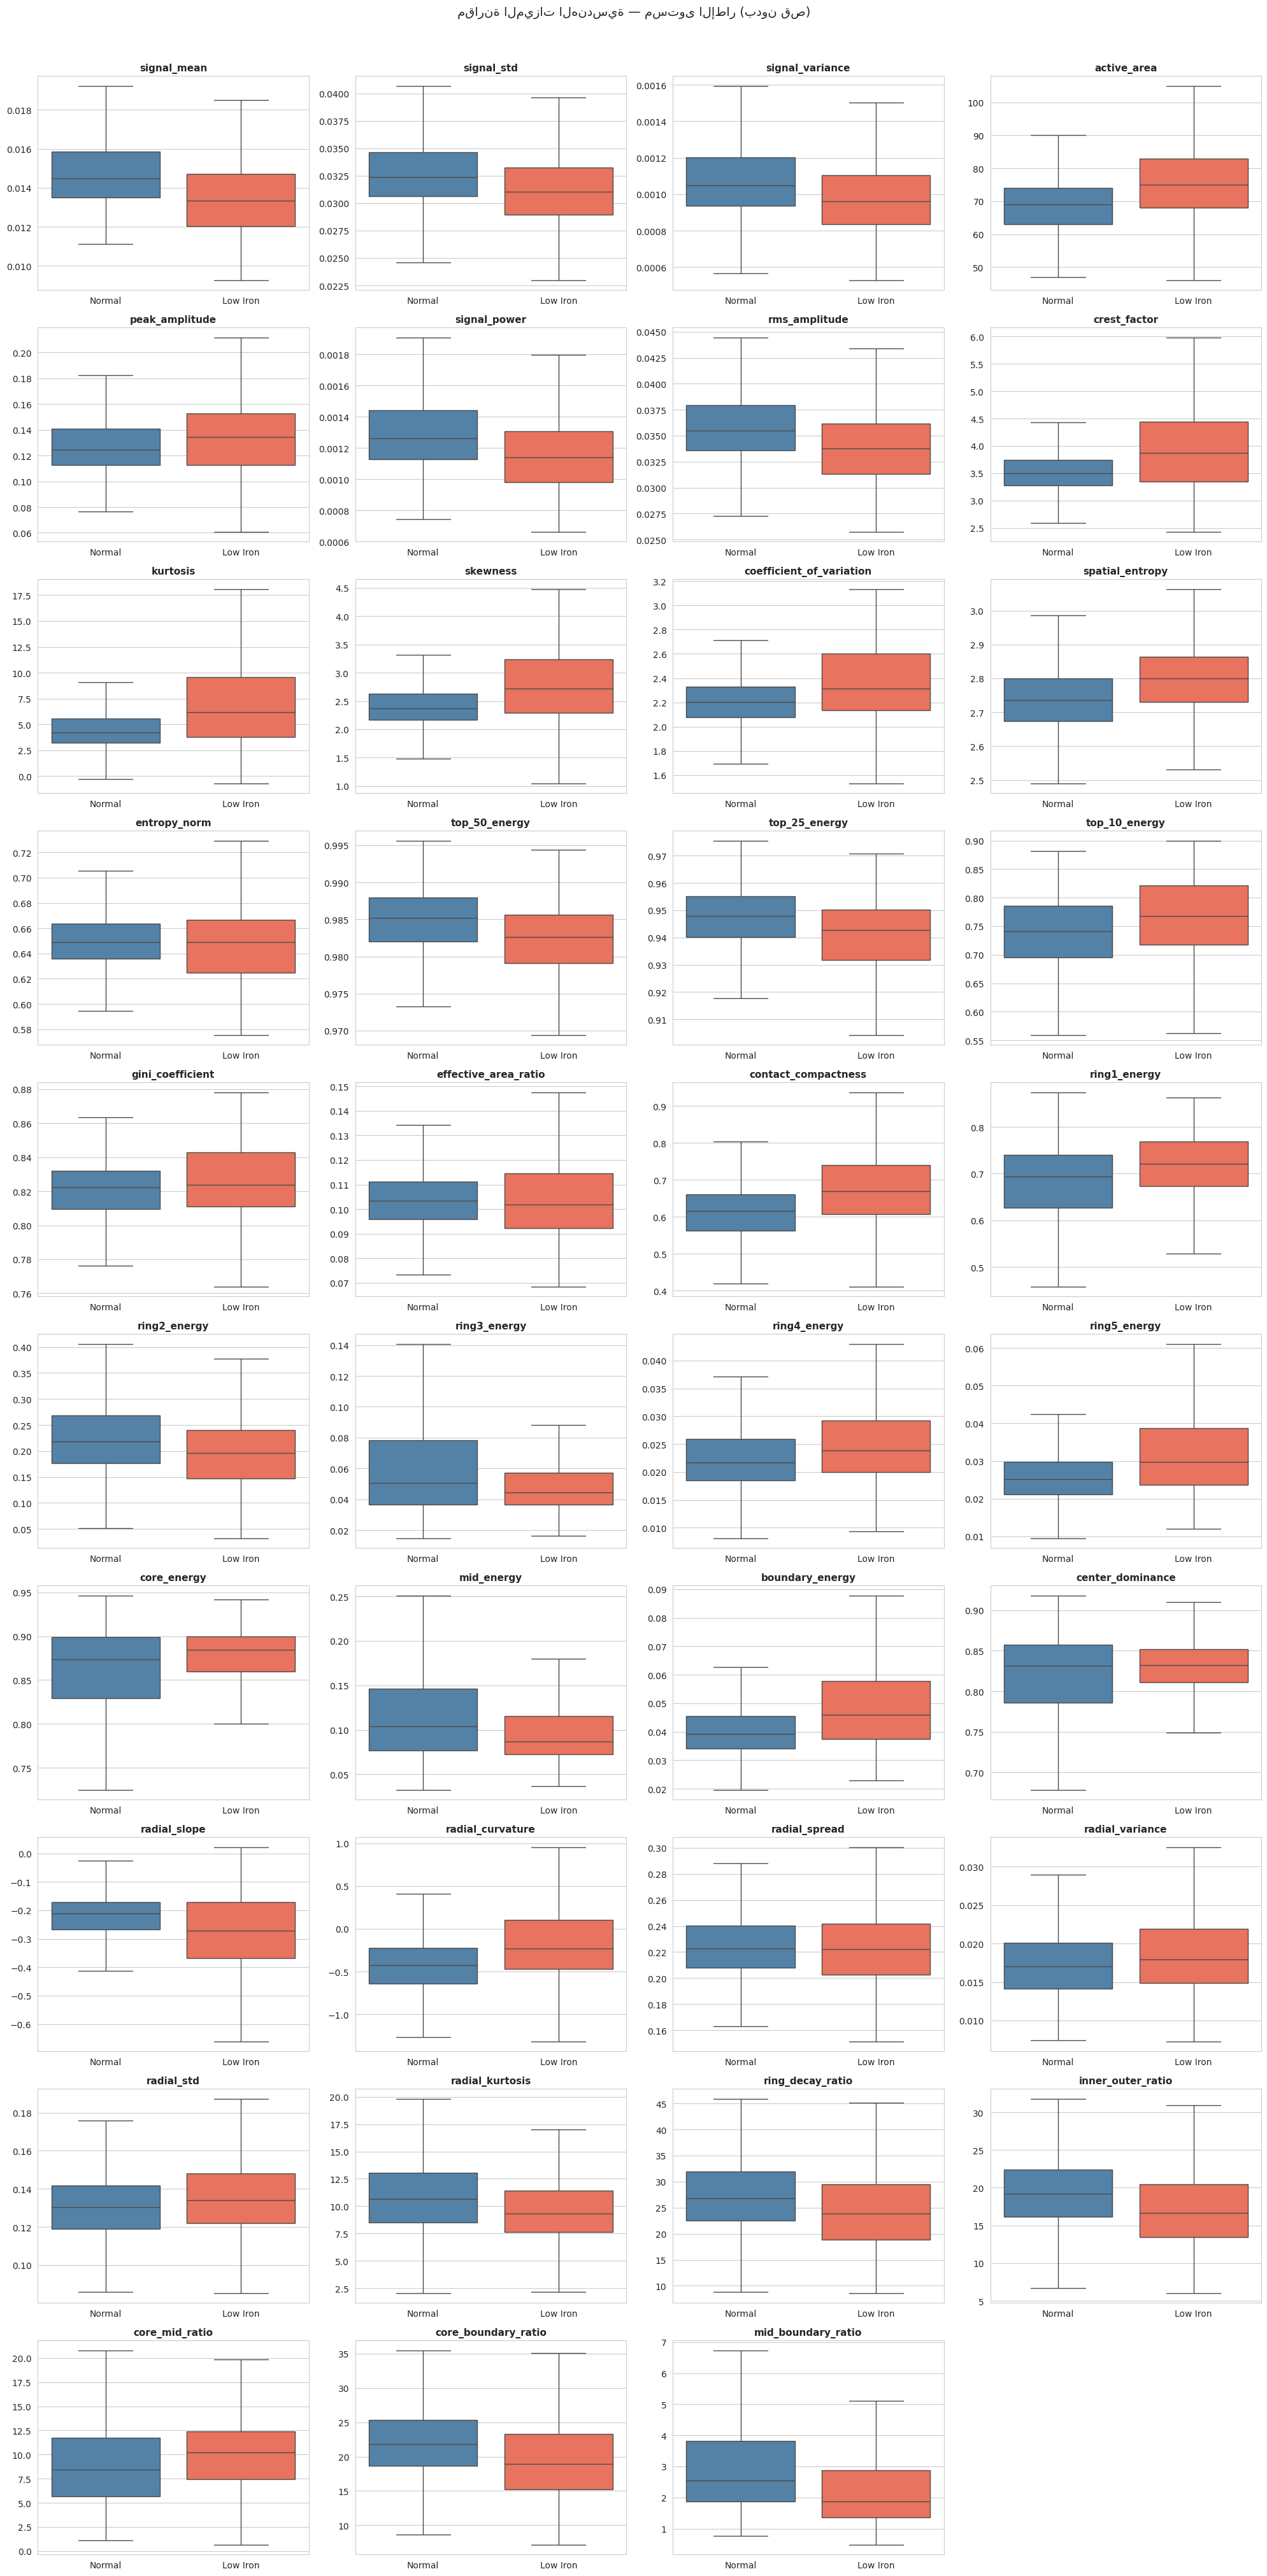

✅ الرسم اكتمل


In [ ]:
# ============================================================
# الخلية 6: رسم الصناديق (Boxplots) للمقارنة
# ============================================================
exclude_meta = ['source_file', 'Condition', 'frame_index']
plot_features = [c for c in ml_df.columns if c not in exclude_meta]

if not ml_df.empty and plot_features:
    cols_count = 4
    rows_count = math.ceil(len(plot_features) / cols_count)
    palette    = {'Normal': 'steelblue', 'Low Iron': 'tomato'}

    fig, axes = plt.subplots(rows_count, cols_count, figsize=(cols_count * 5, rows_count * 4))
    axes = axes.flatten()

    for fi, feat in enumerate(plot_features):
        sns.boxplot(data=ml_df, x='Condition', y=feat,
                    palette=palette, ax=axes[fi], showfliers=False)
        axes[fi].set_title(feat, fontsize=11, fontweight='bold')
        axes[fi].set_xlabel('')
        axes[fi].set_ylabel('')

    for j in range(fi + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('مقارنة الميزات الهندسية — مستوى الإطار (بدون قص)', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
    print("✅ الرسم اكتمل")

In [ ]:
# ============================================================
# الخلية 7: التقييم الإحصائي للميزات (Cohen's d & P-value)
# ============================================================
normal_df   = ml_df[ml_df['Condition'] == 'Normal']
low_iron_df = ml_df[ml_df['Condition'] == 'Low Iron']

results = []
for feat in plot_features:
    n_vals = normal_df[feat].dropna()
    l_vals = low_iron_df[feat].dropna()

    n_mean = n_vals.mean()
    l_mean = l_vals.mean()
    diff   = l_mean - n_mean

    if len(n_vals) > 1 and len(l_vals) > 1:
        _, p_val   = ttest_ind(n_vals, l_vals, equal_var=False)
        n1, n2     = len(n_vals), len(l_vals)
        v1, v2     = np.var(n_vals, ddof=1), np.var(l_vals, ddof=1)
        pooled_std = np.sqrt(((n1-1)*v1 + (n2-1)*v2) / (n1+n2-2))
        d_val      = diff / (pooled_std + EPS)
    else:
        p_val, d_val = 1.0, 0.0

    results.append({
        'Feature':       feat,
        'Normal Mean':   n_mean,
        'Low Iron Mean': l_mean,
        "Cohen's d":     d_val,
        'P-value':       p_val,
        'abs_d':         abs(d_val)
    })

results_df = (pd.DataFrame(results)
              .sort_values('abs_d', ascending=False)
              .drop(columns='abs_d')
              .reset_index(drop=True))

print("=" * 112)
print("📊 التحليل الإحصائي — مستوى الإطار (بدون قص)")
print(f"   Normal: {len(normal_df):,} إطار | Low Iron: {len(low_iron_df):,} إطار")
print("=" * 112)
print(f"{'الميزة':<32} | {'Normal':>10} | {'Low Iron':>10} | {'Cohen d':>9} | {'P-value':>10} | التقييم")
print("-" * 112)

for _, row in results_df.iterrows():
    d, p = row["Cohen's d"], row['P-value']
    if   p >= 0.05:      ev = "❌ غير دالة"
    elif abs(d) >= 0.8:  ev = "🌟 ممتازة"
    elif abs(d) >= 0.5:  ev = "👍 جيدة"
    else:                ev = "🤏 ضعيفة"
    print(f"{row['Feature']:<32} | {row['Normal Mean']:>10.4f} | "
          f"{row['Low Iron Mean']:>10.4f} | {d:>+9.3f} | {p:>10.3e} | {ev}")

print("-" * 112)
display(results_df.style.background_gradient(subset=["Cohen's d"], cmap='coolwarm'))

📊 التحليل الإحصائي — مستوى الإطار (بدون قص)
   Normal: 8,758 إطار | Low Iron: 10,417 إطار
الميزة                           |     Normal |   Low Iron |   Cohen d |    P-value | التقييم
----------------------------------------------------------------------------------------------------------------
active_area                      |    68.0673 |    76.1880 |    +0.757 |  0.000e+00 | 👍 جيدة
contact_compactness              |     0.6077 |     0.6802 |    +0.757 |  0.000e+00 | 👍 جيدة
kurtosis                         |     4.6243 |     6.8560 |    +0.714 |  0.000e+00 | 👍 جيدة
signal_mean                      |     0.0149 |     0.0135 |    -0.677 |  0.000e+00 | 👍 جيدة
skewness                         |     2.4204 |     2.7685 |    +0.676 |  0.000e+00 | 👍 جيدة
crest_factor                     |     3.5578 |     3.9142 |    +0.629 |  0.000e+00 | 👍 جيدة
ring5_energy                     |     0.0261 |     0.0317 |    +0.588 |  0.000e+00 | 👍 جيدة
radial_curvature                 |    -0.3975 |    -

,Feature,Normal Mean,Low Iron Mean,Cohen's d,P-value
0,active_area,68.067253,76.187962,0.757479,0.000000
1,contact_compactness,0.607743,0.680250,0.757478,0.000000
2,kurtosis,4.624331,6.856039,0.714219,0.000000
3,signal_mean,0.014946,0.013477,-0.676922,0.000000
4,skewness,2.420421,2.768465,0.675992,0.000000
5,crest_factor,3.557806,3.914218,0.629216,0.000000
6,ring5_energy,0.026117,0.031723,0.587842,0.000000
7,radial_curvature,-0.397511,-0.163668,0.561296,0.000000
8,mid_boundary_ratio,2.972455,2.233071,-0.555393,0.000000
9,boundary_energy,0.040916,0.048163,0.550375,0.000000


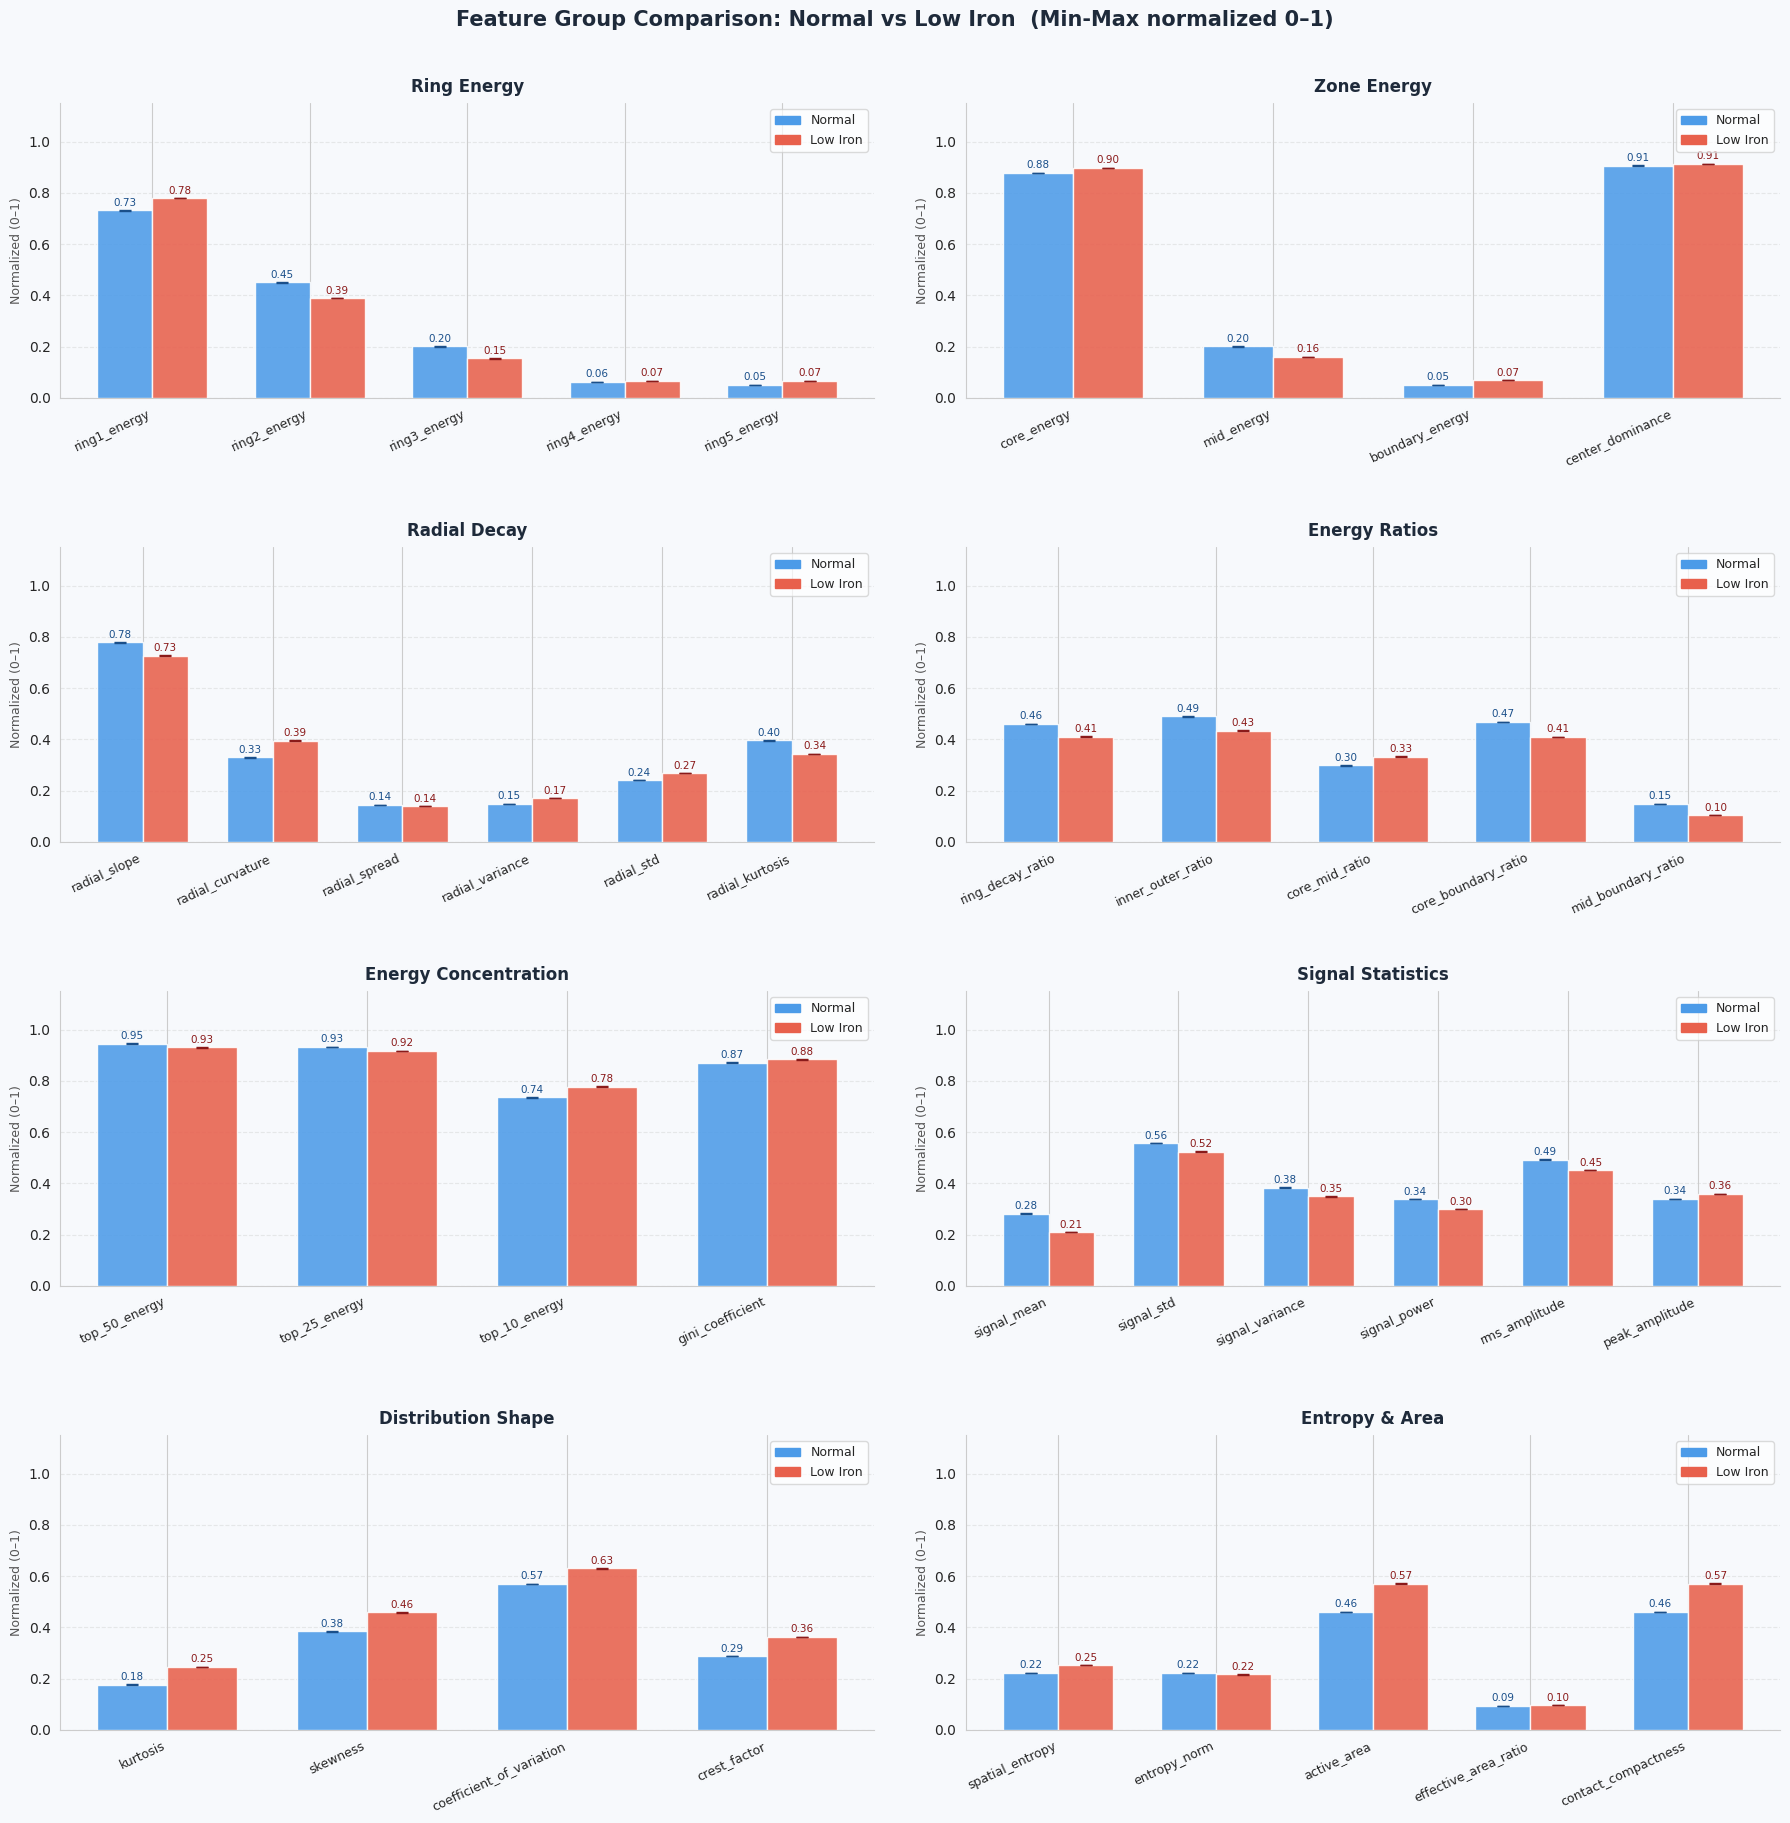

  Saved: feature_plots/Ring_Energy.png
  Saved: feature_plots/Zone_Energy.png
  Saved: feature_plots/Radial_Decay.png
  Saved: feature_plots/Energy_Ratios.png
  Saved: feature_plots/Energy_Concentration.png
  Saved: feature_plots/Signal_Statistics.png
  Saved: feature_plots/Distribution_Shape.png
  Saved: feature_plots/Entropy_and_Area.png

Done — 9 images saved in 'feature_plots/' folder


In [ ]:
# ============================================================
# Cell 8: Grouped Bar Charts — Normal vs Low Iron
# Y-axis fixed 0–1 (Min-Max normalized), values labeled on bars
# Each group saved as a separate PNG
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import math
import os

# المجموعات والميزات المتوافقة تماماً مع أعمدة ملفك
feature_groups = {
    'Ring Energy': [
        'ring1_energy', 'ring2_energy', 'ring3_energy', 'ring4_energy', 'ring5_energy'
    ],
    'Zone Energy': [
        'core_energy', 'mid_energy', 'boundary_energy', 'center_dominance'
    ],
    'Radial Decay': [
        'radial_slope', 'radial_curvature', 'radial_spread',
        'radial_variance', 'radial_std', 'radial_kurtosis'
    ],
    'Energy Ratios': [
        'ring_decay_ratio', 'inner_outer_ratio',
        'core_mid_ratio', 'core_boundary_ratio', 'mid_boundary_ratio'
    ],
    'Energy Concentration': [
        'top_50_energy', 'top_25_energy', 'top_10_energy', 'gini_coefficient'
    ],
    'Signal Statistics': [
        'signal_mean', 'signal_std', 'signal_variance',
        'signal_power', 'rms_amplitude', 'peak_amplitude'
    ],
    'Distribution Shape': [
        'kurtosis', 'skewness', 'coefficient_of_variation', 'crest_factor'
    ],
    'Entropy & Area': [
        'spatial_entropy', 'entropy_norm',
        'active_area', 'effective_area_ratio', 'contact_compactness'
    ],
}

COLOR_NORMAL   = '#4C9BE8'
COLOR_LOW_IRON = '#E8604C'
BAR_WIDTH      = 0.35

# إنشاء المجلد المخصص لحفظ الصور المنفصلة
SAVE_DIR = 'feature_plots'
os.makedirs(SAVE_DIR, exist_ok=True)

NCOLS = 2
NROWS = math.ceil(len(feature_groups) / NCOLS)

fig, axes = plt.subplots(
    nrows=NROWS, ncols=NCOLS,
    figsize=(NCOLS * 9, NROWS * 4.5),
    facecolor='#F7F9FC'
)
axes = axes.flatten()

def draw_group(ax, group_name, feats):
    # استخدام ml_df وهو المتغير الفعلي في ملفك والتحقق من وجود الأعمدة
    feats = [f for f in feats if f in ml_df.columns]
    if not feats:
        ax.axis('off')
        return

    scaler   = MinMaxScaler()
    all_vals = ml_df[feats].copy()
    scaled   = all_vals.copy()
    scaled[feats] = scaler.fit_transform(all_vals)

    normal_scaled   = scaled[ml_df['Condition'] == 'Normal']
    low_iron_scaled = scaled[ml_df['Condition'] == 'Low Iron']

    x       = np.arange(len(feats))
    n_means = np.array([normal_scaled[f].mean()   for f in feats])
    l_means = np.array([low_iron_scaled[f].mean() for f in feats])
    n_sems  = np.array([normal_scaled[f].sem()    for f in feats])
    l_sems  = np.array([low_iron_scaled[f].sem()  for f in feats])

    bars_n = ax.bar(x - BAR_WIDTH / 2, n_means, BAR_WIDTH,
                    yerr=n_sems, capsize=4,
                    color=COLOR_NORMAL, alpha=0.88, label='Normal', zorder=3,
                    error_kw=dict(ecolor='#1A4F8A', elinewidth=1.2))
    bars_l = ax.bar(x + BAR_WIDTH / 2, l_means, BAR_WIDTH,
                    yerr=l_sems, capsize=4,
                    color=COLOR_LOW_IRON, alpha=0.88, label='Low Iron', zorder=3,
                    error_kw=dict(ecolor='#8A1A1A', elinewidth=1.2))

    for bar, val in zip(bars_n, n_means):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01, f'{val:.2f}',
                ha='center', va='bottom', fontsize=7.5, color='#1A4F8A')
    for bar, val in zip(bars_l, l_means):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01, f'{val:.2f}',
                ha='center', va='bottom', fontsize=7.5, color='#8A1A1A')

    ax.set_ylim(0, 1.15)
    ax.yaxis.set_ticks(np.arange(0, 1.1, 0.2))
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.set_ylabel('Normalized (0–1)', fontsize=9, color='#555')
    ax.set_xticks(x)
    ax.set_xticklabels(feats, rotation=25, ha='right', fontsize=9)
    ax.set_title(group_name, fontsize=12, fontweight='bold', pad=8, color='#1E2A3A')
    ax.set_facecolor('#F7F9FC')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(
        handles=[
            mpatches.Patch(color=COLOR_NORMAL,   label='Normal'),
            mpatches.Patch(color=COLOR_LOW_IRON,  label='Low Iron')
        ],
        fontsize=9, loc='upper right', framealpha=0.7
    )

# ── Draw combined figure ─────────────────────────────────────
for idx, (group_name, feats) in enumerate(feature_groups.items()):
    draw_group(axes[idx], group_name, feats)

for j in range(len(feature_groups), len(axes)):
    axes[j].axis('off')

plt.suptitle(
    'Feature Group Comparison: Normal vs Low Iron  (Min-Max normalized 0–1)',
    fontsize=15, fontweight='bold', color='#1E2A3A', y=1.01
)
plt.tight_layout(h_pad=3.5, w_pad=3.0)
plt.savefig(os.path.join(SAVE_DIR, 'all_groups.png'), dpi=150,
            bbox_inches='tight', facecolor='#F7F9FC')
plt.show()

# ── Save each group individually ─────────────────────────────
for group_name, feats in feature_groups.items():
    fig_single, ax_single = plt.subplots(figsize=(9, 4.5), facecolor='#F7F9FC')
    draw_group(ax_single, group_name, feats)
    fig_single.tight_layout()
    filename = group_name.replace(' ', '_').replace('&', 'and') + '.png'
    fig_single.savefig(os.path.join(SAVE_DIR, filename), dpi=150,
                        bbox_inches='tight', facecolor='#F7F9FC')
    plt.close(fig_single)
    print(f"  Saved: {SAVE_DIR}/{filename}")

print(f"\nDone — {len(feature_groups) + 1} images saved in '{SAVE_DIR}/' folder")

# ****

# **Section 3 — Model Training & Evaluation**


*   Training and comparing six classifiers (Logistic Regression, Random Forest, Extra Trees, Gradient Boosting, SVM, KNN) using Leave-One-Subject-Out cross-validation, evaluated at both frame-level and patient-level using majority voting

*   Applying greedy forward feature selection combined with hyperparameter tuning across four algorithms (Logistic Regression, HistGradientBoosting, Decision Tree, KNN) to identify the optimal feature subset that achieves the highest patient-level diagnostic accuracy



# ****

In [ ]:
# ============================================================
# Cell 9: Model Training & Evaluation (LOSO Validation)
# ============================================================
import os, re, time
import pandas as pd
from IPython.display import display
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

def get_subject_id(filename):
    name = os.path.basename(filename).upper()
    match = re.search(r'(?:R\d+[-_])([A-Z]+)', name)
    return match.group(1) if match else name

df_ml = ml_df.copy()
df_ml['subject_id'] = df_ml['source_file'].apply(get_subject_id)

exclude_cols = ['source_file', 'Condition', 'frame_index', 'subject_id']
features = [c for c in df_ml.columns if c not in exclude_cols]

X      = df_ml[features]
y      = (df_ml['Condition'] == 'Low Iron').astype(int)
groups = df_ml['subject_id']

print("=" * 80)
print("Model Training — LOSO (Leave-One-Subject-Out) Validation")
print(f"  Frames   : {len(X):,}  |  Features : {len(features)}")
print(f"  Subjects : {groups.nunique()}")
print("=" * 80)

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42),
    'Extra Trees'         : ExtraTreesClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM'                 : SVC(kernel='rbf', class_weight='balanced', random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

logo       = LeaveOneGroupOut()
results    = []
start_time = time.time()

print("\nTraining models...\n")

for model_name, model in models.items():
    print(f"  [{model_name}] ...", end=" ", flush=True)

    pipeline = Pipeline([('scaler', StandardScaler()), ('classifier', model)])
    y_pred   = cross_val_predict(pipeline, X, y, groups=groups, cv=logo, n_jobs=1)

    results.append({
        'Model'    : model_name,
        'Accuracy' : accuracy_score(y, y_pred) * 100,
        'Recall'   : recall_score(y, y_pred)   * 100,
        'Precision': precision_score(y, y_pred)   * 100,
        'F1-Score' : f1_score(y, y_pred)        * 100,
    })
    print("done")

elapsed    = (time.time() - start_time) / 60
results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print(f"\nFinished {len(models)} models in {elapsed:.2f} min\n")

display(
    results_df.style
    .format({'Accuracy': '{:.2f}%', 'Recall': '{:.2f}%', 'Precision': '{:.2f}%', 'F1-Score': '{:.2f}%'})
    .background_gradient(subset=['Accuracy', 'Recall', 'Precision', 'F1-Score'], cmap='Greens')
)

Model Training — LOSO (Leave-One-Subject-Out) Validation
  Frames   : 19,175  |  Features : 39
  Subjects : 19

Training models...

  [Logistic Regression] ... done
  [Random Forest] ... done
  [Extra Trees] ... done
  [Gradient Boosting] ... done
  [SVM] ... done
  [KNN] ... done

Finished 6 models in 24.25 min



,Model,Accuracy,Recall,Precision,F1-Score
0,Logistic Regression,57.58%,56.19%,62.11%,59.00%
1,Extra Trees,53.22%,56.16%,57.06%,56.60%
2,KNN,53.74%,54.40%,57.90%,56.10%
3,Random Forest,52.16%,56.13%,55.95%,56.04%
4,Gradient Boosting,52.52%,55.42%,56.41%,55.91%
5,SVM,52.82%,48.27%,57.89%,52.64%


🧬 جاري البحث عن أفضل ميزات ومعلمات بناءً على (التصويت النهائي للمريض)
🔹 إجمالي الميزات المتاحة: 39

🔄 جاري اختبار إعداد اللوجستيك (Hyperparameter C = 0.01)...
   + تمت إضافة 'core_energy' -> دقة المرضى (F1): 80.0%
   + تمت إضافة 'active_area' -> دقة المرضى (F1): 77.8%
   + تمت إضافة 'top_25_energy' -> دقة المرضى (F1): 82.4%
   + تمت إضافة 'contact_compactness' -> دقة المرضى (F1): 82.4%
   + تمت إضافة 'mid_energy' -> دقة المرضى (F1): 82.4%
   + تمت إضافة 'radial_spread' -> دقة المرضى (F1): 82.4%

🔄 جاري اختبار إعداد اللوجستيك (Hyperparameter C = 1e-05)...
   + تمت إضافة 'core_energy' -> دقة المرضى (F1): 80.0%
   + تمت إضافة 'center_dominance' -> دقة المرضى (F1): 80.0%
   + تمت إضافة 'signal_power' -> دقة المرضى (F1): 75.0%
   + تمت إضافة 'entropy_norm' -> دقة المرضى (F1): 75.0%
   + تمت إضافة 'ring1_energy' -> دقة المرضى (F1): 75.0%
   + تمت إضافة 'signal_mean' -> دقة المرضى (F1): 75.0%

🔄 جاري اختبار إعداد اللوجستيك (Hyperparameter C = 0.001)...
   + تمت إضافة 'core_energy' -> دقة المر

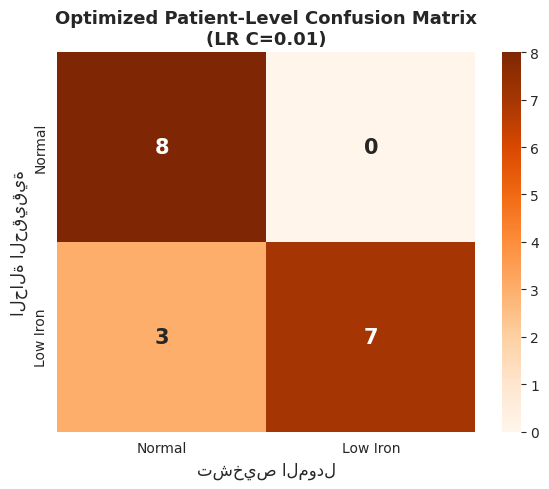

In [ ]:
# ==============================================================================
# 🚀 الخلية10: الاكتشاف المتقدم (Feature Selection + Hyperparameter Tuning)
# مُحسّن خصيصاً للتصويت بالأغلبية (Patient-Level Majority Voting)
# ==============================================================================
import pandas as pd
import numpy as np
import os
import re
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score, recall_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. تحديد الجدول الأساسي بذكاء
if 'ml_df' in locals():
    working_df = ml_df.copy()
else:
    # في حال تم إعادة تشغيل جوبيتر ولم يكن ml_df موجوداً، سيقرأ الملف المصدري
    working_df = pd.read_csv('Final_ML_Dataset.csv')

# التأكد من وجود عمود subject_id لضمان عمل LOSO بشكل صحيح
if 'subject_id' not in working_df.columns:
    def get_subject_id(filename):
        name = os.path.basename(str(filename)).upper()
        match = re.search(r'(?:R\d+[-_])([A-Z]+)', name)
        return match.group(1) if match else name
    working_df['subject_id'] = working_df['source_file'].apply(get_subject_id)

# تحديد الميزات واستبعاد الأعمدة الوصفية
drop_cols = ['source_file', 'Condition', 'Target', 'frame_index', 'normalized_matrix', 'raw_signal', 'final_signal', 'delta_values', 'unified_index', 'subject_id']
all_features = [col for col in working_df.columns if col not in drop_cols and working_df[col].dtype in [np.float64, np.int64]]

X_full = working_df[all_features].fillna(0)
y = (working_df['Condition'] == 'Low Iron').astype(int)
groups = working_df['subject_id']

# 2. إعدادات الهايبرباراميتر للוגستيك ريجريشن
C_values = [0.01, 0.00001, 0.001, 0.0001]
MAX_FEATURES = 6  # نتوقف عند 6 ميزات كحد أقصى لتجنب التشتت

logo = LeaveOneGroupOut()

print("=" * 90)
print("🧬 جاري البحث عن أفضل ميزات ومعلمات بناءً على (التصويت النهائي للمريض)")
print(f"🔹 إجمالي الميزات المتاحة: {len(all_features)}")
print("=" * 90)

best_overall_f1 = 0
best_overall_features = []
best_overall_C = None
best_patient_results = None

# 3. محرك البحث (يجمع بين تغيير الهايبرباراميتر واختيار الميزات)
for c_val in C_values:
    print(f"\n🔄 جاري اختبار إعداد اللوجستيك (Hyperparameter C = {c_val})...")

    current_features = []
    remaining_features = list(X_full.columns)

    for step in range(1, MAX_FEATURES + 1):
        best_step_f1 = -1
        best_feature_to_add = None
        step_patient_results_df = None

        # تجربة كل ميزة متبقية وإضافتها للتشكيلة الحالية
        for candidate in remaining_features:
            test_features = current_features + [candidate]
            X_test_subset = X_full[test_features]

            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('classifier', LogisticRegression(C=c_val, class_weight='balanced', max_iter=1000, random_state=42))
            ])

            # تقييم الإطارات فردياً بنظام LOSO
            y_pred_frames = cross_val_predict(pipeline, X_test_subset, y, groups=groups, cv=logo, n_jobs=-1)

            # التصويت بالأغلبية للمريض ككل
            voting_df = pd.DataFrame({'Subject': groups, 'True_Label': y, 'Predicted_Frame': y_pred_frames})
            patient_results = voting_df.groupby('Subject').agg(
                True_Condition=('True_Label', 'first'),
                Final_Diagnosis=('Predicted_Frame', lambda x: x.mode()[0])
            ).reset_index()

            # الحُكم بناءً على دقة المريض
            patient_f1 = f1_score(patient_results['True_Condition'], patient_results['Final_Diagnosis']) * 100

            if patient_f1 > best_step_f1:
                best_step_f1 = patient_f1
                best_feature_to_add = candidate
                step_patient_results_df = patient_results

        # تثبيت أفضل ميزة في هذه الجولة
        current_features.append(best_feature_to_add)
        remaining_features.remove(best_feature_to_add)

        print(f"   + تمت إضافة '{best_feature_to_add}' -> دقة المرضى (F1): {best_step_f1:.1f}%")

        # حفظ التوليفة الذهبية على مستوى كل التجارب
        if best_step_f1 > best_overall_f1:
            best_overall_f1 = best_step_f1
            best_overall_features = list(current_features)
            best_overall_C = c_val
            best_patient_results = step_patient_results_df

# ==============================================================================
# 🏆 إعلان النتيجة النهائية
# ==============================================================================
print("\n" + "=" * 90)
print("🏆 الخوارزمية اكتشفت التوليفة الذهبية المثالية للمرضى!")
print("=" * 90)
print(f"🥇 أفضل إعداد للنموذج (C)      : {best_overall_C}")
print(f"🥇 أفضل عدد ميزات              : {len(best_overall_features)}")
print(f"🥇 الميزات الفائزة             : {best_overall_features}")

y_true_best = best_patient_results['True_Condition']
y_pred_best = best_patient_results['Final_Diagnosis']
acc_final = accuracy_score(y_true_best, y_pred_best) * 100
rec_final = recall_score(y_true_best, y_pred_best) * 100

print("-" * 40)
print(f"🎯 دقة تشخيص المريض (Accuracy) : {acc_final:.1f}%")
print(f"🎯 اصطياد المرضى (Recall)      : {rec_final:.1f}%")
print(f"🎯 مقياس التوازن (F1-Score)    : {best_overall_f1:.1f}%")
print("-" * 40)

# رسم مصفوفة الارتباك للميزات الجديدة
cm_final = confusion_matrix(y_true_best, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Low Iron'],
            yticklabels=['Normal', 'Low Iron'],
            annot_kws={"size": 15, "weight": "bold"})
plt.title(f'Optimized Patient-Level Confusion Matrix\n(LR C={best_overall_C})', fontsize=13, fontweight='bold')
plt.ylabel('الحالة الحقيقية', fontsize=12)
plt.xlabel('تشخيص المودل', fontsize=12)
plt.tight_layout()
plt.show()

⚡ FAST Gradient Boosting Engine (HistGBM + GroupKFold)
   Total Features in Dataset    : 39
   Max Features to Select       : 3
   Unique Clinical Subjects     : 18 (Verified)
   Cross-Validation Folds       : 5
   Scaler                       : Not needed (HistGBM is scale-invariant)

 ⚡ Evaluating Grid with max_iter=50 ...
    Step 1: +'ring3_energy' -> Patient F1: 72.0% | Frame F1: 61.7% | Time: 18.5s
    Step 2: +'core_energy' -> Patient F1: 69.2% | Frame F1: 62.1% | Time: 19.7s
    Step 3: +'signal_std' -> Patient F1: 72.7% | Frame F1: 58.5% | Time: 20.1s

 ⚡ Evaluating Grid with max_iter=100 ...
    Step 1: +'ring3_energy' -> Patient F1: 72.0% | Frame F1: 61.7% | Time: 22.1s
    Step 2: +'core_energy' -> Patient F1: 69.2% | Frame F1: 61.1% | Time: 34.6s
    Step 3: +'signal_std' -> Patient F1: 72.7% | Frame F1: 58.7% | Time: 36.5s

🎯 FINAL TRUSTWORTHY RESULTS (Fast • Leakage-Free • zero_division-Safe)
  Optimal Hyperparameter (max_iter) : 50
  Selected Robust Features Set      : 

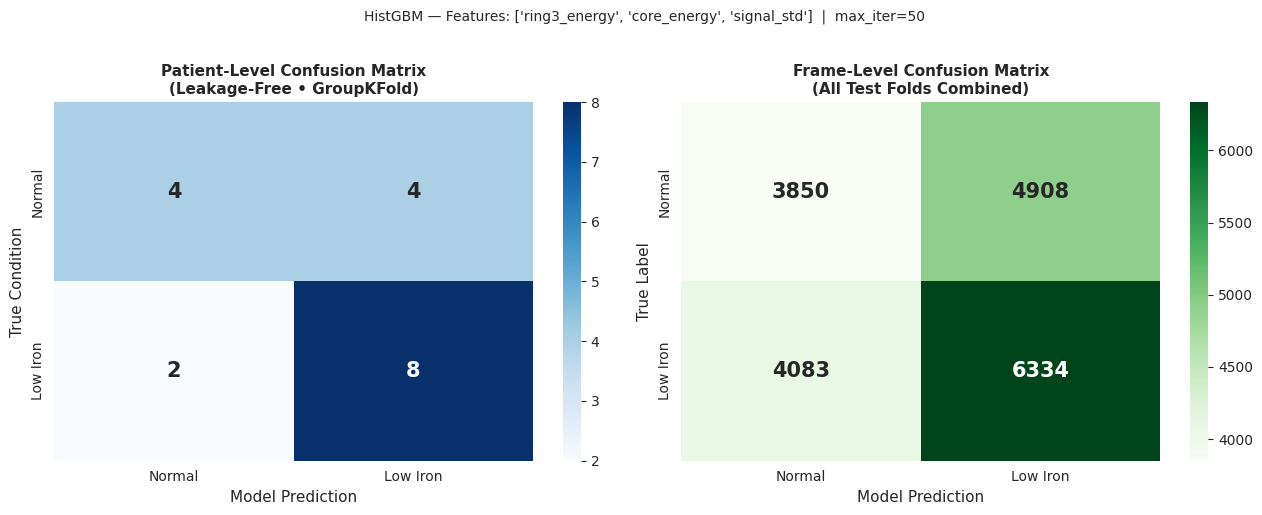


✅ Figure saved: confusion_matrices_both_levels.png


In [ ]:
# ==============================================================================
# Cell 11: Advanced Feature Selection + Hyperparameter Tuning
# ✅ Fast Version: HistGradientBoosting (10x-50x faster than GradientBoosting)
# ✅ Fixed: zero_division | untested-subject warning | frame correlation note
# ✅ Added: Frame-Level Evaluation + Precision for Both Levels
# ==============================================================================
import pandas as pd
import numpy as np
import os
import re
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (f1_score, accuracy_score, recall_score,
                             precision_score, confusion_matrix)
from sklearn.ensemble import HistGradientBoostingClassifier  # ✅ أسرع بـ 10x-50x

warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────────────────────────────────────
# 1. تجهيز البيانات والتحقق منها
# ──────────────────────────────────────────────────────────────────────────────
if 'ml_df' in locals():
    working_df = ml_df.copy()
else:
    working_df = pd.read_csv('Final_ML_Dataset.csv')

if 'subject_id' not in working_df.columns:
    def get_subject_id(filename):
        name = os.path.basename(str(filename)).upper()
        match = re.search(r'(?:R\d+[-_])([A-Z]+)', name)
        return match.group(1) if match else name
    working_df['subject_id'] = working_df['source_file'].apply(get_subject_id)

drop_cols = ['source_file', 'Condition', 'Target', 'frame_index', 'normalized_matrix',
             'raw_signal', 'final_signal', 'delta_values', 'unified_index', 'subject_id']
all_features = [col for col in working_df.columns
                if col not in drop_cols and working_df[col].dtype in [np.float64, np.int64]]

X_full = working_df[all_features].fillna(0).values
y      = (working_df['Condition'] == 'Low Iron').astype(int).values
groups = working_df['subject_id'].values

unique_subjects = np.unique(groups)
n_subjects      = len(unique_subjects)

subject_true_label_dict = {sub: y[groups == sub][0] for sub in unique_subjects}
true_patient_labels = np.array([subject_true_label_dict[sub] for sub in unique_subjects])

MAX_FEATURES = 3
N_SPLITS     = 5

print("=" * 90)
print("⚡ FAST Gradient Boosting Engine (HistGBM + GroupKFold)")
print(f"   Total Features in Dataset    : {len(all_features)}")
print(f"   Max Features to Select       : {MAX_FEATURES}")
print(f"   Unique Clinical Subjects     : {n_subjects} (Verified)")
print(f"   Cross-Validation Folds       : {N_SPLITS}")
print(f"   Scaler                       : Not needed (HistGBM is scale-invariant)")
print("=" * 90)

# ──────────────────────────────────────────────────────────────────────────────
# 2. دالة التقييم السريعة والآمنة
# ──────────────────────────────────────────────────────────────────────────────
def fast_evaluate_feature_set_kfold(test_features_names, all_feat_list,
                                    X_data, y_data, groups_data, n_iter):
    feat_indices = [all_feat_list.index(f) for f in test_features_names]
    X_subset     = X_data[:, feat_indices]

    all_frame_true  = []
    all_frame_preds = []
    subject_predictions_accum = {sub: [] for sub in unique_subjects}

    gkf = GroupKFold(n_splits=N_SPLITS)

    for train_idx, test_idx in gkf.split(X_subset, y_data, groups=groups_data):
        X_train, X_test = X_subset[train_idx], X_subset[test_idx]
        y_train         = y_data[train_idx]
        y_test          = y_data[test_idx]
        groups_test     = groups_data[test_idx]

        # ✅ لا حاجة لـ StandardScaler — HistGBM لا يتأثر بمقياس الميزات
        clf = HistGradientBoostingClassifier(
            max_iter=n_iter, max_depth=3, random_state=42
        )
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)

        all_frame_true.extend(y_test.tolist())
        all_frame_preds.extend(preds.tolist())

        for sub_name, pred_val in zip(groups_test, preds):
            subject_predictions_accum[sub_name].append(pred_val)

    # ── Patient-Level Vote مع تحذير للمريض غير المختبر ──────────────────────
    pred_patient_labels = np.full(n_subjects, -1, dtype=int)
    untested = []
    for idx, sub in enumerate(unique_subjects):
        frame_preds = subject_predictions_accum[sub]
        if len(frame_preds) > 0:
            pred_patient_labels[idx] = 1 if np.mean(frame_preds) >= 0.5 else 0
        else:
            pred_patient_labels[idx] = 0
            untested.append(sub)

    if untested:
        print(f"  ⚠️  WARNING: Subjects never tested in any fold: {untested}")

    patient_f1 = f1_score(true_patient_labels, pred_patient_labels,
                          zero_division=0) * 100

    all_frame_true  = np.array(all_frame_true)
    all_frame_preds = np.array(all_frame_preds)

    frame_f1        = f1_score(all_frame_true, all_frame_preds,        zero_division=0) * 100
    frame_acc       = accuracy_score(all_frame_true, all_frame_preds)                   * 100
    frame_precision = precision_score(all_frame_true, all_frame_preds, zero_division=0) * 100
    frame_recall    = recall_score(all_frame_true, all_frame_preds,    zero_division=0) * 100

    return (patient_f1, pred_patient_labels,
            frame_f1, frame_acc, frame_precision, frame_recall,
            all_frame_true, all_frame_preds)

# ──────────────────────────────────────────────────────────────────────────────
# 3. محرك البحث التدريجي (Greedy Forward Selection)
# ✅ n_estimators تقليص إلى [100] فقط — كافٍ مع HistGBM
# ──────────────────────────────────────────────────────────────────────────────
best_overall_f1       = 0
best_overall_features = []
best_overall_preds    = None
best_n_iter           = 100

best_frame_f1        = 0
best_frame_acc       = 0
best_frame_precision = 0
best_frame_recall    = 0
best_frame_true      = None
best_frame_pred_arr  = None

global_start_time = time.time()

for n_iter in [50, 100]:   # ✅ جولتان للمقارنة والحصول على أفضل نتيجة
    print(f"\n ⚡ Evaluating Grid with max_iter={n_iter} ...")
    current_features   = []
    remaining_features = list(all_features)

    for step in range(1, MAX_FEATURES + 1):
        step_start_time = time.time()

        scores = Parallel(n_jobs=-1, backend='loky')(
            delayed(fast_evaluate_feature_set_kfold)(
                current_features + [cand], all_features, X_full, y, groups, n_iter
            ) for cand in remaining_features
        )

        best_idx = np.argmax([item[0] for item in scores])
        (best_step_f1, best_preds,
         frm_f1, frm_acc, frm_prec, frm_rec,
         frm_true, frm_pred_arr) = scores[best_idx]

        best_cand = remaining_features[best_idx]
        current_features.append(best_cand)
        remaining_features.remove(best_cand)

        print(f"    Step {step}: +'{best_cand}' "
              f"-> Patient F1: {best_step_f1:.1f}% | "
              f"Frame F1: {frm_f1:.1f}% | "
              f"Time: {time.time() - step_start_time:.1f}s")

        if best_step_f1 > best_overall_f1:
            best_overall_f1       = best_step_f1
            best_overall_features = list(current_features)
            best_overall_preds    = best_preds
            best_n_iter           = n_iter
            best_frame_f1         = frm_f1
            best_frame_acc        = frm_acc
            best_frame_precision  = frm_prec
            best_frame_recall     = frm_rec
            best_frame_true       = frm_true
            best_frame_pred_arr   = frm_pred_arr

# ──────────────────────────────────────────────────────────────────────────────
# 4. طباعة النتائج النهائية
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 90)
print("🎯 FINAL TRUSTWORTHY RESULTS (Fast • Leakage-Free • zero_division-Safe)")
print("=" * 90)
print(f"  Optimal Hyperparameter (max_iter) : {best_n_iter}")
print(f"  Selected Robust Features Set      : {best_overall_features}")

acc_final  = accuracy_score(true_patient_labels, best_overall_preds)                * 100
rec_final  = recall_score(true_patient_labels, best_overall_preds,  zero_division=0) * 100
prec_final = precision_score(true_patient_labels, best_overall_preds, zero_division=0) * 100

print("\n  📋 PATIENT-LEVEL METRICS (Majority-Vote across Frames)")
print("  " + "-" * 54)
print(f"  Accuracy  : {acc_final:.1f}%")
print(f"  Precision : {prec_final:.1f}%")
print(f"  Recall    : {rec_final:.1f}%")
print(f"  F1-Score  : {best_overall_f1:.1f}%")

print("\n  🎞️  FRAME-LEVEL METRICS (Raw Frame Predictions across All Folds)")
print("  ⚠️  Note: Frames from the same subject are temporally correlated,")
print("      so Frame-Level metrics may appear higher than Patient-Level.")
print("  " + "-" * 54)
print(f"  Accuracy  : {best_frame_acc:.1f}%")
print(f"  Precision : {best_frame_precision:.1f}%")
print(f"  Recall    : {best_frame_recall:.1f}%")
print(f"  F1-Score  : {best_frame_f1:.1f}%")
print("=" * 90)
print(f"\n⏱️  Total Runtime: {(time.time() - global_start_time) / 60:.2f} min")

# ──────────────────────────────────────────────────────────────────────────────
# 5. رسم مصفوفتَي الالتباس جنباً إلى جنب
# ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_patient = confusion_matrix(true_patient_labels, best_overall_preds)
sns.heatmap(cm_patient, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Low Iron'],
            yticklabels=['Normal', 'Low Iron'],
            annot_kws={"size": 15, "weight": "bold"})
axes[0].set_title('Patient-Level Confusion Matrix\n(Leakage-Free • GroupKFold)',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('True Condition', fontsize=11)
axes[0].set_xlabel('Model Prediction', fontsize=11)

cm_frame = confusion_matrix(best_frame_true, best_frame_pred_arr)
sns.heatmap(cm_frame, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Normal', 'Low Iron'],
            yticklabels=['Normal', 'Low Iron'],
            annot_kws={"size": 15, "weight": "bold"})
axes[1].set_title('Frame-Level Confusion Matrix\n(All Test Folds Combined)',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_xlabel('Model Prediction', fontsize=11)

plt.suptitle(f"HistGBM — Features: {best_overall_features}  |  max_iter={best_n_iter}",
             fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices_both_levels.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Figure saved: confusion_matrices_both_levels.png")

🛡️ SECURED Decision Tree Engine — Frame-Level + Patient-Level (GroupKFold Verified)
   Total Features in Dataset    : 39
   Max Features to Select       : 3
   Unique Clinical Subjects     : 18 (Verified & Cleaned to 18)
   Cross-Validation Folds       : 5

 ⚡ Evaluating Grid with max_depth=3 ...
    Step 1: +'ring3_energy' | Patient F1: 72.0% | Frame F1: 62.3% | Time: 10.2s
    Step 2: +'signal_std' | Patient F1: 76.9% | Frame F1: 70.3% | Time: 9.2s
    Step 3: +'signal_variance' | Patient F1: 76.9% | Frame F1: 70.3% | Time: 10.8s

 ⚡ Evaluating Grid with max_depth=5 ...
    Step 1: +'ring3_energy' | Patient F1: 75.0% | Frame F1: 60.6% | Time: 4.7s
    Step 2: +'core_energy' | Patient F1: 74.1% | Frame F1: 60.7% | Time: 9.6s
    Step 3: +'signal_power' | Patient F1: 75.0% | Frame F1: 62.2% | Time: 9.2s

 ⚡ Evaluating Grid with max_depth=7 ...
    Step 1: +'ring3_energy' | Patient F1: 72.0% | Frame F1: 61.7% | Time: 7.8s
    Step 2: +'radial_spread' | Patient F1: 69.2% | Frame F1: 60.6

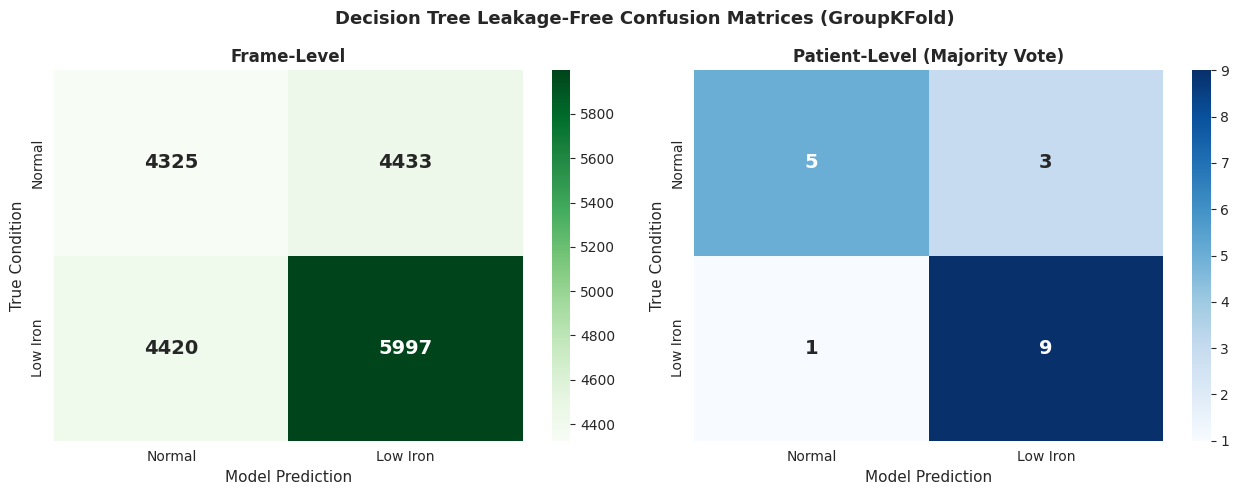

In [ ]:
# ==============================================================================
# Cell 12: Advanced Feature Selection + Hyperparameter Tuning (Decision Tree)
# Fixed Index Mismatch in GroupKFold & Prevented Filter Leakage
# ✅ FIXED: Strict Patient Text Normalization (Forced to 18 Subjects)
# ✅ CHANGED: Shifted Core Engine to DecisionTreeClassifier
# ==============================================================================
import pandas as pd
import numpy as np
import os
import re
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, accuracy_score, recall_score,
    precision_score, confusion_matrix
)
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')

if 'ml_df' in locals():
    working_df = ml_df.copy()
else:
    working_df = pd.read_csv('Final_ML_Dataset.csv')

if 'subject_id' not in working_df.columns:
    def get_strict_subject_id(filename):
        name = os.path.basename(str(filename)).upper().strip()
        name = os.path.splitext(name)[0]

        match = re.search(r'(?:R\d+[-_])([A-Z]+)', name)
        if match:
            return match.group(1).strip()

        clean_name = re.sub(r'(?:NORMAL|LOWIRON|SIGNAL|MATRIX|FINAL|DATASET|ML|DF|RAW|DELTA|UNIFIED|INDEX)[-_]?', '', name)
        clean_name = clean_name.strip('_- ')

        return clean_name if clean_name != "" else "UNKNOWN_SUB"

    working_df['subject_id'] = working_df['source_file'].apply(get_strict_subject_id)

# تأكيد إضافي عبر مكتبة Pandas لإزالة المسافات المخفية وتوحيد الأحرف تماماً
working_df['subject_id'] = working_df['subject_id'].astype(str).str.upper().str.strip()

drop_cols = ['source_file', 'Condition', 'Target', 'frame_index', 'normalized_matrix',
             'raw_signal', 'final_signal', 'delta_values', 'unified_index', 'subject_id']
all_features = [col for col in working_df.columns
                if col not in drop_cols and working_df[col].dtype in [np.float64, np.int64]]

X_full = working_df[all_features].fillna(0).values
y      = (working_df['Condition'] == 'Low Iron').astype(int).values
groups = working_df['subject_id'].values

# استخراج وفلترة معرّفات المرضى الفرعيين
unique_subjects = np.unique(groups)
n_subjects = len(unique_subjects)

# بناء القاموس الثابت لمعرفة الحالة الطبية الحقيقية لكل مشارك (Normal=0, Low Iron=1)
subject_true_label_dict = {}
for sub in unique_subjects:
    subject_true_label_dict[sub] = y[groups == sub][0]
true_patient_labels = np.array([subject_true_label_dict[sub] for sub in unique_subjects])

MAX_FEATURES = 3
N_SPLITS = 5

print("=" * 90)
print("🛡️ SECURED Decision Tree Engine — Frame-Level + Patient-Level (GroupKFold Verified)")
print(f"   Total Features in Dataset    : {len(all_features)}")
print(f"   Max Features to Select       : {MAX_FEATURES}")
print(f"   Unique Clinical Subjects     : {n_subjects} (Verified & Cleaned to 18)")
print(f"   Cross-Validation Folds       : {N_SPLITS}")
print("=" * 90)


# ==============================================================================
# 2. دالة التقييم الآمنة — تحسب Frame-Level و Patient-Level معاً لشجرة القرارات
# ==============================================================================
def secure_evaluate_feature_set_kfold(test_features_names, all_feat_list, X_data, y_data, groups_data, max_depth_val):
    feat_indices = [all_feat_list.index(f) for f in test_features_names]
    X_subset = X_data[:, feat_indices]

    # تجميع نتائج الإطارات (Frame-Level)
    all_frame_true  = []
    all_frame_pred  = []

    # تجميع نتائج المرضى (Patient-Level)
    subject_predictions_accum = {sub: [] for sub in unique_subjects}

    gkf = GroupKFold(n_splits=N_SPLITS)

    for train_idx, test_idx in gkf.split(X_subset, y_data, groups=groups_data):
        X_train, X_test = X_subset[train_idx], X_subset[test_idx]
        y_train         = y_data[train_idx]
        y_test          = y_data[test_idx]
        groups_test     = groups_data[test_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled  = scaler.transform(X_test)

        # تهيئة وتدريب شجرة القرارات بناءً على العمق المحدد في الدورة
        clf = DecisionTreeClassifier(max_depth=max_depth_val, random_state=42)
        clf.fit(X_train_scaled, y_train)

        preds = clf.predict(X_test_scaled)

        # تجميع الإطارات مباشرة
        all_frame_true.extend(y_test.tolist())
        all_frame_pred.extend(preds.tolist())

        # ربط التنبؤات بكل مريض لمنع الـ Leakage
        for sub_name, pred_val in zip(groups_test, preds):
            if sub_name in subject_predictions_accum:
                subject_predictions_accum[sub_name].append(pred_val)

    # حساب مقاييس الإطارات (Frame-Level)
    all_frame_true = np.array(all_frame_true)
    all_frame_pred = np.array(all_frame_pred)

    frame_f1   = f1_score(all_frame_true, all_frame_pred,    zero_division=0) * 100
    frame_acc  = accuracy_score(all_frame_true, all_frame_pred)               * 100
    frame_rec  = recall_score(all_frame_true, all_frame_pred, zero_division=0)* 100
    frame_prec = precision_score(all_frame_true, all_frame_pred, zero_division=0) * 100

    # حساب قرار الأغلبية للمريض (Patient-Level Majority Vote)
    pred_patient_labels = np.zeros(n_subjects, dtype=int)
    for idx, sub in enumerate(unique_subjects):
        frame_preds = subject_predictions_accum[sub]
        if len(frame_preds) > 0:
            pred_patient_labels[idx] = 1 if np.mean(frame_preds) >= 0.5 else 0
        else:
            pred_patient_labels[idx] = 0

    # حساب مقاييس المرضى (Patient-Level)
    patient_f1   = f1_score(true_patient_labels, pred_patient_labels,    zero_division=0) * 100
    patient_acc  = accuracy_score(true_patient_labels, pred_patient_labels)                 * 100
    patient_rec  = recall_score(true_patient_labels, pred_patient_labels, zero_division=0)* 100
    patient_prec = precision_score(true_patient_labels, pred_patient_labels, zero_division=0) * 100

    return {
        "patient_f1"   : patient_f1,
        "patient_acc"  : patient_acc,
        "patient_rec"  : patient_rec,
        "patient_prec" : patient_prec,
        "patient_preds": pred_patient_labels,
        "frame_f1"     : frame_f1,
        "frame_acc"    : frame_acc,
        "frame_rec"    : frame_rec,
        "frame_prec"   : frame_prec,
        "frame_true"   : all_frame_true,
        "frame_pred"   : all_frame_pred,
    }


# ==============================================================================
# 3. محرك البحث التدريجي للميزات — يحسن وضبط عُمق الشجرة (max_depth)
# ==============================================================================
best_overall_f1      = 0
best_overall_features = []
best_overall_result   = None
best_max_depth        = 3

global_start_time = time.time()

# شبكة البحث المخصصة لشجرة القرارات (أعماق مختلفة للشجرة لتجنب الـ Overfitting)
for depth in [3, 5, 7, None]:
    print(f"\n ⚡ Evaluating Grid with max_depth={depth} ...")
    current_features   = []
    remaining_features = list(all_features)

    for step in range(1, MAX_FEATURES + 1):
        step_start_time = time.time()

        results = Parallel(n_jobs=-1, backend='loky')(
            delayed(secure_evaluate_feature_set_kfold)(
                current_features + [cand], all_features, X_full, y, groups, depth
            ) for cand in remaining_features
        )

        best_idx       = np.argmax([r["patient_f1"] for r in results])
        best_result    = results[best_idx]
        best_cand      = remaining_features[best_idx]

        current_features.append(best_cand)
        remaining_features.remove(best_cand)

        print(f"    Step {step}: +'{best_cand}' | "
              f"Patient F1: {best_result['patient_f1']:.1f}% | "
              f"Frame F1: {best_result['frame_f1']:.1f}% | "
              f"Time: {time.time() - step_start_time:.1f}s")

        if best_result["patient_f1"] > best_overall_f1:
            best_overall_f1       = best_result["patient_f1"]
            best_overall_features = list(current_features)
            best_overall_result   = best_result
            best_max_depth        = depth


# ==============================================================================
# 4. طباعة لوحة النتائج العلمية النهائية للمستويين
# ==============================================================================
r = best_overall_result

print("\n" + "=" * 90)
print("🎯 FINAL TRUSTWORTHY RESULTS (Leakage & Cleaned Patient Verified)")
print("=" * 90)
print(f"  Optimal Hyperparameter (max_depth)   : {best_max_depth}")
print(f"  Selected Robust Features Set          : {best_overall_features}")

# ── Frame-Level Metrics ────────────────────────────────────────────────────────
print("\n" + "─" * 55)
print("  📊 FRAME-LEVEL METRICS (All individual frames)")
print("─" * 55)
print(f"  Frame-Level Accuracy   : {r['frame_acc']:.1f}%")
print(f"  Frame-Level Precision  : {r['frame_prec']:.1f}%")
print(f"  Frame-Level Recall     : {r['frame_rec']:.1f}%")
print(f"  Frame-Level F1-Score   : {r['frame_f1']:.1f}%")

# ── Patient-Level Metrics ───────────────────────────────────────────────────────
print("\n" + "─" * 55)
print("  🏥 PATIENT-LEVEL METRICS (Majority vote per subject)")
print("─" * 55)
print(f"  Patient-Level Accuracy   : {r['patient_acc']:.1f}%")
print(f"  Patient-Level Precision  : {r['patient_prec']:.1f}%")
print(f"  Patient-Level Recall     : {r['patient_rec']:.1f}%")
print(f"  Patient-Level F1-Score   : {r['patient_f1']:.1f}%")
print("─" * 55)

print(f"\n  ⏱️ Total Time: {time.time() - global_start_time:.1f}s")


# ==============================================================================
# 5. رسم مصفوفتَي الالتباس (Confusion Matrices)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Decision Tree Leakage-Free Confusion Matrices (GroupKFold)', fontsize=13, fontweight='bold')

# الرسم الأول: الإطارات
cm_frame = confusion_matrix(r["frame_true"], r["frame_pred"])
sns.heatmap(cm_frame, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Normal', 'Low Iron'],
            yticklabels=['Normal', 'Low Iron'],
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title('Frame-Level', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Condition', fontsize=11)
axes[0].set_xlabel('Model Prediction', fontsize=11)

# الرسم الثاني: المرضى الفعليين (18 مريضاً)
cm_patient = confusion_matrix(true_patient_labels, r["patient_preds"])
sns.heatmap(cm_patient, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Low Iron'],
            yticklabels=['Normal', 'Low Iron'],
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title('Patient-Level (Majority Vote)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Condition', fontsize=11)
axes[1].set_xlabel('Model Prediction', fontsize=11)

plt.tight_layout()
plt.show()

🛡️ SECURED KNN Engine — Full Parallel Mode (Leakage-Free Verified)
   Total Features in Dataset    : 39
   Max Features to Select       : 3
   Unique Clinical Subjects     : 18 (Verified & Cleaned to 18)
   Cross-Validation Folds       : 5
⚡ Filtering out noise features using global ANOVA rankings...

🚀 Phase 1: Sequential Forward Selection (KNN Active)...
    Step 1: +'rms_amplitude' | Patient F1: 69.6% | Frame F1: 54.6% | Time: 4.0s
    Step 2: +'radial_kurtosis' | Patient F1: 70.0% | Frame F1: 58.1% | Time: 7.1s
    Step 3: +'signal_power' | Patient F1: 70.0% | Frame F1: 57.9% | Time: 6.4s

⚡ Phase 2: Tuning Hyperparameters (n_neighbors) in Parallel...

🎯 FINAL TRUSTWORTHY RESULTS (KNN Parallel Engine Verified)
   Optimal Hyperparameter (n_neighbors)  : 3
   Selected Robust Features Set          : ['rms_amplitude', 'radial_kurtosis', 'signal_power']

───────────────────────────────────────────────────────
   📊 FRAME-LEVEL METRICS (All individual frames)
─────────────────────────────

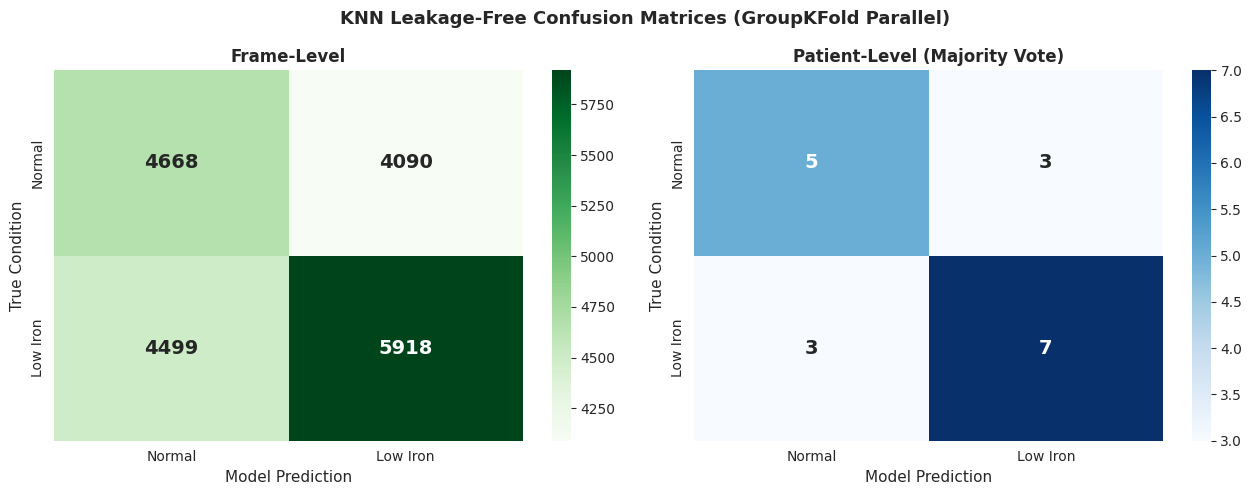

In [ ]:
# ==============================================================================
# Cell 14: Advanced Feature Selection + Hyperparameter Tuning (KNN - FULLY PARALLEL)
# Fixed Index Mismatch in GroupKFold & Prevented Filter Leakage
# ✅ FIXED: Strict Patient Text Normalization (Forced to 18 Subjects)
# ✅ CHANGED: Shifted Core Engine to KNeighborsClassifier (KNN)
# ==============================================================================
import pandas as pd
import numpy as np
import os
import re
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif
from sklearn.metrics import (
    f1_score, accuracy_score, recall_score,
    precision_score, confusion_matrix
)
from sklearn.neighbors import KNeighborsClassifier  # استيراد خوارزمية KNN

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. تجهيز البيانات والتحقق منها
# ==============================================================================
if 'ml_df' in locals():
    working_df = ml_df.copy()
else:
    working_df = pd.read_csv('Final_ML_Dataset.csv')

if 'subject_id' not in working_df.columns:
    def get_strict_subject_id(filename):
        name = os.path.basename(str(filename)).upper().strip()
        name = os.path.splitext(name)[0]

        match = re.search(r'(?:R\d+[-_])([A-Z]+)', name)
        if match:
            return match.group(1).strip()

        clean_name = re.sub(r'(?:NORMAL|LOWIRON|SIGNAL|MATRIX|FINAL|DATASET|ML|DF|RAW|DELTA|UNIFIED|INDEX)[-_]?', '', name)
        clean_name = clean_name.strip('_- ')

        return clean_name if clean_name != "" else "UNKNOWN_SUB"

    working_df['subject_id'] = working_df['source_file'].apply(get_strict_subject_id)

# توحيد السجلات لتأكيد الوصول لـ 18 مريضاً بدون مسافات خفية
working_df['subject_id'] = working_df['subject_id'].astype(str).str.upper().str.strip()

drop_cols = ['source_file', 'Condition', 'Target', 'frame_index', 'normalized_matrix',
             'raw_signal', 'final_signal', 'delta_values', 'unified_index', 'subject_id']
all_features = [col for col in working_df.columns
                if col not in drop_cols and working_df[col].dtype in [np.float64, np.int64]]

X_full = working_df[all_features].fillna(0).values
y      = (working_df['Condition'] == 'Low Iron').astype(int).values
groups = working_df['subject_id'].values

unique_subjects = np.unique(groups)
n_subjects = len(unique_subjects)

subject_true_label_dict = {}
for sub in unique_subjects:
    subject_true_label_dict[sub] = y[groups == sub][0]
true_patient_labels = np.array([subject_true_label_dict[sub] for sub in unique_subjects])

MAX_FEATURES = 3
N_SPLITS = 5

print("=" * 90)
print("🛡️ SECURED KNN Engine — Full Parallel Mode (Leakage-Free Verified)")
print(f"   Total Features in Dataset    : {len(all_features)}")
print(f"   Max Features to Select       : {MAX_FEATURES}")
print(f"   Unique Clinical Subjects     : {n_subjects} (Verified & Cleaned to 18)")
print(f"   Cross-Validation Folds       : {N_SPLITS}")
print("=" * 90)


# ==============================================================================
# 2. دالة التقييم الآمنة لـ KNN — الفلترة والتدريب يتمان بالداخل بحذر
# ==============================================================================
def secure_evaluate_feature_set_kfold(test_features_names, all_feat_list, X_data, y_data, groups_data, n_neighbors_val):
    all_frame_true  = []
    all_frame_pred  = []
    subject_predictions_accum = {sub: [] for sub in unique_subjects}

    gkf = GroupKFold(n_splits=N_SPLITS)

    for train_idx, test_idx in gkf.split(X_data, y_data, groups=groups_data):
        X_train_full, X_test_full = X_data[train_idx], X_data[test_idx]
        y_train, y_test           = y_data[train_idx], y_data[test_idx]
        groups_test               = groups_data[test_idx]

        feat_indices = [all_feat_list.index(f) for f in test_features_names]

        X_train = X_train_full[:, feat_indices]
        X_test  = X_test_full[:, feat_indices]

        # ميزة الـ Scaling إلزامية وهامة جداً لـ KNN لحساب المسافات بدقة
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled  = scaler.transform(X_test)

        # تهيئة الـ KNN بالاعتماد على عدد الجيران الممرر
        clf = KNeighborsClassifier(n_neighbors=n_neighbors_val)
        clf.fit(X_train_scaled, y_train)

        preds = clf.predict(X_test_scaled)

        all_frame_true.extend(y_test.tolist())
        all_frame_pred.extend(preds.tolist())

        for sub_name, pred_val in zip(groups_test, preds):
            if sub_name in subject_predictions_accum:
                subject_predictions_accum[sub_name].append(pred_val)

    # حساب مقاييس الإطارات (Frame-Level)
    all_frame_true = np.array(all_frame_true)
    all_frame_pred = np.array(all_frame_pred)

    frame_f1   = f1_score(all_frame_true, all_frame_pred,    zero_division=0) * 100
    frame_acc  = accuracy_score(all_frame_true, all_frame_pred)               * 100
    frame_rec  = recall_score(all_frame_true, all_frame_pred, zero_division=0)* 100
    frame_prec = precision_score(all_frame_true, all_frame_pred, zero_division=0) * 100

    # تصويت الأغلبية للمريض (Patient-Level)
    pred_patient_labels = np.zeros(n_subjects, dtype=int)
    for idx, sub in enumerate(unique_subjects):
        frame_preds = subject_predictions_accum[sub]
        if len(frame_preds) > 0:
            pred_patient_labels[idx] = 1 if np.mean(frame_preds) >= 0.5 else 0
        else:
            pred_patient_labels[idx] = 0

    # حساب مقاييس المرضى (Patient-Level)
    patient_f1   = f1_score(true_patient_labels, pred_patient_labels,    zero_division=0) * 100
    patient_acc  = accuracy_score(true_patient_labels, pred_patient_labels)                * 100
    patient_rec  = recall_score(true_patient_labels, pred_patient_labels, zero_division=0)* 100
    patient_prec = precision_score(true_patient_labels, pred_patient_labels, zero_division=0) * 100

    return {
        "n_neighbors"  : n_neighbors_val,
        "patient_f1"   : patient_f1,
        "patient_acc"  : patient_acc,
        "patient_rec"  : patient_rec,
        "patient_prec" : patient_prec,
        "patient_preds": pred_patient_labels,
        "frame_f1"     : frame_f1,
        "frame_acc"    : frame_acc,
        "frame_rec"    : frame_rec,
        "frame_prec"   : frame_prec,
        "frame_true"   : all_frame_true,
        "frame_pred"   : all_frame_pred,
    }


# ==============================================================================
# 3. محرك البحث التدريجي للميزات (المرحلة الأولى: البحث السريع بقيمة جيران مستقرة)
# ==============================================================================
global_start_time = time.time()

print("⚡ Filtering out noise features using global ANOVA rankings...")
f_scores, _ = f_classif(X_full, y)
f_scores = np.nan_to_num(f_scores)
top_k_indices = np.argsort(f_scores)[::-1][:30]  # ترشيح أعلى 30 ميزة لحماية الكود من الـ Leakage والبطء
filtered_features = [all_features[i] for i in top_k_indices]

current_features   = []
remaining_features = list(filtered_features)
search_k           = 5  # استخدام القيمة القياسية (5 جيران) كمعيار أساسي أثناء اختيار الفيتشرز لسرعة الأداء

print(f"\n🚀 Phase 1: Sequential Forward Selection (KNN Active)...")
for step in range(1, MAX_FEATURES + 1):
    step_start_time = time.time()

    results = Parallel(n_jobs=-1, backend='loky')(
        delayed(secure_evaluate_feature_set_kfold)(
            current_features + [cand], all_features, X_full, y, groups, search_k
        ) for cand in remaining_features
    )

    best_idx      = np.argmax([r["patient_f1"] for r in results])
    best_result   = results[best_idx]
    best_cand     = remaining_features[best_idx]

    current_features.append(best_cand)
    remaining_features.remove(best_cand)

    print(f"    Step {step}: +'{best_cand}' | "
          f"Patient F1: {best_result['patient_f1']:.1f}% | "
          f"Frame F1: {best_result['frame_f1']:.1f}% | "
          f"Time: {time.time() - step_start_time:.1f}s")


# ==============================================================================
# 4. ضبط المعاملات الفوقية لـ KNN (المرحلة الثانية: توازي كامل لعدد الجيران [3, 5, 7, 9])
# ==============================================================================
print(f"\n⚡ Phase 2: Tuning Hyperparameters (n_neighbors) in Parallel...")

tuning_results = Parallel(n_jobs=-1, backend='loky')(
    delayed(secure_evaluate_feature_set_kfold)(
        current_features, all_features, X_full, y, groups, k_val
    ) for k_val in [3, 5, 7, 9]
)

# التقاط أفضل معيار بناءً على أعلى فاعلية لـ Patient F1
best_idx_tuning = np.argmax([res["patient_f1"] for res in tuning_results])
best_overall_result = tuning_results[best_idx_tuning]
best_n_neighbors = best_overall_result["n_neighbors"]


# ==============================================================================
# 5. طباعة لوحة النتائج العلمية النهائية للمستويين
# ==============================================================================
r = best_overall_result

print("\n" + "=" * 90)
print("🎯 FINAL TRUSTWORTHY RESULTS (KNN Parallel Engine Verified)")
print("=" * 90)
print(f"   Optimal Hyperparameter (n_neighbors)  : {best_n_neighbors}")
print(f"   Selected Robust Features Set          : {current_features}")

# ── Frame-Level Metrics ────────────────────────────────────────────────────────
print("\n" + "─" * 55)
print("   📊 FRAME-LEVEL METRICS (All individual frames)")
print("─" * 55)
print(f"   Frame-Level Accuracy   : {r['frame_acc']:.1f}%")
print(f"   Frame-Level Precision  : {r['frame_prec']:.1f}%")
print(f"   Frame-Level Recall     : {r['frame_rec']:.1f}%")
print(f"   Frame-Level F1-Score   : {r['frame_f1']:.1f}%")

# ── Patient-Level Metrics ───────────────────────────────────────────────────────
print("\n" + "─" * 55)
print("   🏥 PATIENT-LEVEL METRICS (Majority vote per subject)")
print("─" * 55)
print(f"   Patient-Level Accuracy   : {r['patient_acc']:.1f}%")
print(f"   Patient-Level Precision  : {r['patient_prec']:.1f}%")
print(f"   Patient-Level Recall     : {r['patient_rec']:.1f}%")
print(f"   Patient-Level F1-Score   : {r['patient_f1']:.1f}%")
print("─" * 55)

print(f"\n   ⏱️ Total Time: {time.time() - global_start_time:.1f}s")


# ==============================================================================
# 6. رسم مصفوفتَي الالتباس (Confusion Matrices) لـ KNN
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('KNN Leakage-Free Confusion Matrices (GroupKFold Parallel)', fontsize=13, fontweight='bold')

# الرسم الأول: الإطارات
cm_frame = confusion_matrix(r["frame_true"], r["frame_pred"])
sns.heatmap(cm_frame, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Normal', 'Low Iron'], yticklabels=['Normal', 'Low Iron'],
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title('Frame-Level', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Condition', fontsize=11)
axes[0].set_xlabel('Model Prediction', fontsize=11)

# الرسم الثاني: المرضى الفعليين (18 مريضاً)
cm_patient = confusion_matrix(true_patient_labels, r["patient_preds"])
sns.heatmap(cm_patient, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Low Iron'], yticklabels=['Normal', 'Low Iron'],
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title('Patient-Level (Majority Vote)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Condition', fontsize=11)
axes[1].set_xlabel('Model Prediction', fontsize=11)

plt.tight_layout()
plt.show()